In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

supermanrtyty_experiment_results_json_path = kagglehub.dataset_download('supermanrtyty/experiment-results-json')

print('Data source import complete.')


# Vizura LLM from Scratch: Research Based Assessment
### TPU-Optimized Notebook (v5e-1 / v2-8 / v3-8 compatible)

**Assignment Objective:**
Train a GPT-style Large Language Model from scratch on a Project Gutenberg text corpus
and systematically study how architectural choices and hyperparameters affect training dynamics.

**Experiments Covered:**
- Baseline: Standard model trained with default configuration
- Experiment 1A: Effect of learning rate (1e-4, 1e-3, 1e-2) at fixed epochs
- Experiment 1B: Effect of number of training epochs (5 to 50+)
- Experiment 2: Effect of transformer depth (1, 3, 5, 7, 12 layers)
- Experiment 3: Effect of number of attention heads (1, 2, 4, 8)
- Experiment 4: Ablation studies — removing LayerNorm, Residual connections, and FFN

**How to Run:**
Execute cells top-to-bottom in order. Each experiment cell is self-contained.
All results are automatically saved to JSON and CSV. All plots are saved as PNG files.

## Cell 1: Install Dependencies

**What this cell does:**
Installs two Python packages that are not included in the default Colab environment:
- `tiktoken`: OpenAI's fast tokenizer. We use the GPT-2 vocabulary (50,257 tokens) so our
  model can tokenize arbitrary English text into integer IDs that map to subword units.
- `matplotlib`: Standard Python plotting library used to visualize training and validation
  loss curves across all experiments.

**Why these are needed:**
Without `tiktoken` we cannot convert raw text into token IDs, which is the required input
format for the transformer. Without `matplotlib` we cannot produce the plots required
by the assignment rubric.

In [ ]:
# ── Kaggle TPU / GPU / CPU — Dependency Setup ─────────────────────────────
# IMPORTANT: On Kaggle TPU, torch and torch_xla are PRE-INSTALLED and tightly
# coupled to the TPU runtime. NEVER uninstall or reinstall torch/torchvision/
# torchaudio here — doing so breaks the XLA binding and causes:
#   ValueError: numpy.dtype size changed (binary incompatibility)
# Only install packages that are genuinely missing.

import subprocess, sys

def _pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# tiktoken and matplotlib are not pre-installed on Kaggle
_pip('tiktoken')
_pip('matplotlib')

# Verify environment is healthy
import torch, numpy as np
print('torch  :', torch.__version__)
print('numpy  :', np.__version__)
print('CUDA   :', torch.cuda.is_available())

# Check if TPU (torch_xla) is available
try:
    import torch_xla.core.xla_model as xm
    print('TPU    : available -', xm.xla_device())
except ImportError:
    print('TPU    : not available (running on GPU/CPU)')

print('\n✅ Environment ready. Proceed to next cell.')



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


torch  : 2.8.0+cpu
numpy  : 2.4.3
CUDA   : False


/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


/tmp/ipykernel_73/3285390911.py:26: DeprecationWarning: Use torch_xla.device instead
  print('TPU    : available -', xm.xla_device())


TPU    : available - xla:0

✅ Environment ready. Proceed to next cell.


E0000 00:00:1777012010.449337      73 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:238


## Cell 2: Device Detection — TPU / GPU / CPU

**What this cell does:**
Automatically detects the available hardware accelerator and sets a global `device` variable
that all subsequent cells use when moving tensors to the correct compute backend.
It also sets a `USING_TPU` flag so TPU-specific calls (such as `xm.mark_step()` and
`xm.optimizer_step()`) are only triggered when actually running on a TPU.

**Why this matters:**
PyTorch Tensors and models must explicitly be placed on the same device. If a tensor is
on CPU but the model is on TPU the forward pass will crash. Centralising device detection
here means we never have to repeat it and experiments are portable across hardware.

**TPU note:**
On Google Colab select Runtime > Change runtime type > TPU to enable the v5e-1 core.
The `torch_xla` library bridges PyTorch operations to XLA (Accelerated Linear Algebra),
Google's compiler that optimises tensor programs for TPU hardware.

In [ ]:
import torch

def get_device():
    # TPU
    try:
        import torch_xla.core.xla_model as xm
        device = xm.xla_device()
        print("TPU detected:", device)
        return device, True
    except ImportError:
        pass

    # GPU
    if torch.cuda.is_available():
        try:
            name = torch.cuda.get_device_name(0)
            cap  = torch.cuda.get_device_capability(0)

            print(f"GPU detected: {name} | Compute Capability: {cap}")

            # REAL TEST (this is enough)
            x = torch.rand(1, device="cuda")
            y = x * 2
            torch.cuda.synchronize()

            print("GPU usable ✅")
            return torch.device("cuda"), False

        except Exception as e:
            print("GPU detected but NOT usable:", e)

    print("Falling back to CPU")
    return torch.device("cpu"), False

## Cell 3: Dataset Download and Corpus Construction

**What this cell does:**
Downloads three public-domain books from Project Gutenberg and concatenates them into a
single plain-text file called `corpus.txt`. The three books chosen are:
- *Pride and Prejudice* by Jane Austen (~700 KB)
- *Frankenstein* by Mary Shelley (~430 KB)
- *The Adventures of Sherlock Holmes* by Arthur Conan Doyle (~580 KB)

Together they form a corpus of roughly 1.7 million characters (~420,000 tokens), which is
large enough to observe meaningful training dynamics within a reasonable training time.

**Why multiple books?**
A single short text would cause the model to memorise it quickly and show no interesting
learning curve. Mixing genres and authors makes the task harder and more representative
of real language modelling.

**Why Project Gutenberg?**
All texts are in the public domain, have no copyright restrictions, and are available as
clean UTF-8 plain text — ideal for tokenisation without additional preprocessing.

**Reproducibility:**
Files are only downloaded if they do not already exist on disk, so re-running this cell
after a disconnection is safe and fast.

In [ ]:
import urllib.request
import os

BOOKS = {
    "pride_and_prejudice": "https://www.gutenberg.org/files/1342/1342-0.txt",
    "frankenstein":        "https://www.gutenberg.org/files/84/84-0.txt",
    "sherlock_holmes":     "https://www.gutenberg.org/files/1661/1661-0.txt",
}

combined_text = ""
print("Downloading and assembling corpus ...")
print("-" * 50)
for name, url in BOOKS.items():
    fname = f"{name}.txt"
    if not os.path.exists(fname):
        print(f"  Downloading: {name} ...")
        urllib.request.urlretrieve(url, fname)
    with open(fname, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    combined_text += text + "\n\n"
    print(f"  Loaded '{name}': {len(text):,} characters")

with open("corpus.txt", "w", encoding="utf-8") as f:
    f.write(combined_text)

print("-" * 50)
print(f"Total corpus size : {len(combined_text):,} characters")
print(f"Corpus saved to   : corpus.txt")

--------------------------------------------------
  Downloading: pride_and_prejudice ...


  Loaded 'pride_and_prejudice': 728,846 characters
  Downloading: frankenstein ...


  Loaded 'frankenstein': 419,434 characters
  Downloading: sherlock_holmes ...


  Loaded 'sherlock_holmes': 581,425 characters
--------------------------------------------------
Total corpus size : 1,729,711 characters
Corpus saved to   : corpus.txt


## Cell 4: Tokenizer and Dataset Pipeline

**What this cell does:**
Defines two classes and one helper function that form the complete data pipeline:

1. **`GPTDataset`** — A PyTorch `Dataset` that takes raw text, tokenises it with the
   GPT-2 BPE tokenizer, and produces overlapping input/target pairs using a sliding
   window of size `max_length` and step size `stride`. For each window position `i`,
   the input sequence is tokens `[i, i+max_length)` and the target is tokens
   `[i+1, i+max_length+1)` — a one-position right shift. This is the standard
   next-token prediction objective used to train all autoregressive language models.

2. **`make_loaders`** — Splits the corpus into a training set (90% of text) and a
   validation set (10%), instantiates `GPTDataset` for each split, and wraps them
   in `DataLoader` objects that batch and shuffle samples efficiently.
   `num_workers=0` is required on TPU because multiprocess data loading conflicts
   with XLA's process model.

**Why sliding windows?**
A stride smaller than `max_length` creates overlapping samples, increasing the effective
dataset size and ensuring every token participates in training regardless of where it
falls relative to chunk boundaries.

**Why train/val split on text, not samples?**
Splitting the raw text string before tokenising ensures no token from the validation
set ever appears in a training window, providing a clean holdout.

In [ ]:
import tiktoken
import numpy as np
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding("gpt2")
print(f"Tokenizer loaded. Vocabulary size: {tokenizer.n_vocab:,} tokens")


class GPTDataset(Dataset):
    """
    Sliding-window next-token-prediction dataset.

    For each window of `max_length` tokens, the input is the window and the
    target is the same window shifted one position to the right. The model
    learns to predict the next token at every position simultaneously.

    Parameters
    ----------
    text       : raw UTF-8 string of the full text split
    tokenizer  : tiktoken encoder
    max_length : context window size (number of tokens per sample)
    stride     : step between consecutive windows (< max_length gives overlap)
    """
    def __init__(self, text, tokenizer, max_length=128, stride=64):
        self.input_ids  = []
        self.target_ids = []
        token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
        for i in range(0, len(token_ids) - max_length, stride):
            inp = token_ids[i       : i + max_length    ]
            tgt = token_ids[i + 1  : i + max_length + 1]
            self.input_ids.append(torch.tensor(inp, dtype=torch.long))
            self.target_ids.append(torch.tensor(tgt, dtype=torch.long))
        print(f"  Dataset ready: {len(self.input_ids):,} samples  |  "
              f"seq_len={max_length}  |  stride={stride}")

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def make_loaders(text, batch_size=32, max_length=128, stride=64, val_frac=0.1):
    """
    Split text into train/val, create datasets and DataLoaders.

    Returns
    -------
    train_loader, val_loader : torch DataLoader objects
    """
    split_idx    = int(len(text) * (1 - val_frac))
    train_text   = text[:split_idx]
    val_text     = text[split_idx:]
    print(f"Corpus split: {len(train_text):,} chars train / {len(val_text):,} chars val")
    train_ds     = GPTDataset(train_text, tokenizer, max_length, stride)
    val_ds       = GPTDataset(val_text,   tokenizer, max_length, stride)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              drop_last=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              drop_last=True,  num_workers=0)
    print(f"DataLoaders ready: {len(train_loader)} train batches | {len(val_loader)} val batches")
    return train_loader, val_loader


with open("corpus.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"Corpus loaded: {len(raw_text):,} characters")

Tokenizer loaded. Vocabulary size: 50,257 tokens
Corpus loaded: 1,729,711 characters


## Cell 5: GPT Model Architecture

**What this cell does:**
Defines the complete GPT-style transformer model from scratch, broken into six
modular classes. Each class is designed to be independently toggled for ablation
experiments via boolean flags (`use_norm`, `use_residual`, `use_ffn`).

### Component breakdown

**LayerNorm / IdentityNorm**
Layer Normalisation rescales each token's embedding to have zero mean and unit variance
before it enters the attention or FFN sub-layers. This stabilises gradient magnitudes
during training and allows higher learning rates. `IdentityNorm` is a no-op placeholder
used in the ablation experiment that removes normalisation entirely.

**GELU Activation**
Gaussian Error Linear Unit — a smooth, differentiable approximation to ReLU.
Empirically outperforms ReLU in transformer FFNs because its non-zero gradient
for negative inputs prevents dead neurons.

**FeedForward / IdentityFFN**
A two-layer MLP applied independently to every token position. The hidden dimension
is 4× the embedding dimension (standard GPT design). This sub-layer is responsible
for storing factual knowledge and performing position-wise feature transformations.
`IdentityFFN` replaces it with a pass-through for the ablation study.

**MultiHeadAttention**
Scaled dot-product attention computed in parallel across `num_heads` subspaces.
Each head learns different relational patterns (e.g., syntactic agreement, coreference).
The causal mask ensures each position can only attend to earlier positions, making
generation well-defined. The mask is built dynamically from the actual sequence
length `T` at each forward call — this is critical for TPU compatibility (see note below).

**TransformerBlock**
Combines one attention sub-layer and one FFN sub-layer, each preceded by LayerNorm
(Pre-LN design) and followed by a residual (skip) connection. The residual path
provides a gradient highway that prevents vanishing gradients in deep networks.

**GPTModel**
The full model: token embedding table, learnable positional embeddings,
`n_layers` transformer blocks, a final LayerNorm, and a linear projection to
vocabulary logits. The output projection shares weights with the token embedding
table (weight tying), which reduces parameters by ~13M and improves perplexity.

### TPU / XLA Fix — negative slice indices
XLA (the compiler behind TPU) compiles tensor operations into a static graph.
Negative slice positions like `idx[:, -128:]` are resolved at Python level but
XLA validates the constant against the tensor's compiled shape descriptor, which
uses a limited-range signed integer. Passing -128 exceeds that range and raises
`"Value out of range (expected to be in range of [-8, 7], got -128)"`.

The fix in `generate()`:
```python
seq_len  = idx.shape[1]                          # plain Python int, host-side
start    = max(0, seq_len - self.context_length) # always >= 0
idx_cond = idx[:, start:]                        # XLA sees a non-negative constant
```
`idx.shape[1]` is evaluated eagerly on the Python host before XLA traces anything,
so `start` is a concrete non-negative integer baked into the compiled graph.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# ─────────────────────────────────────────────────────────────────
# Layer Normalisation
# ─────────────────────────────────────────────────────────────────
class LayerNorm(nn.Module):
    """
    Custom Layer Normalisation.
    Normalises each token embedding to zero mean and unit variance,
    then applies learnable scale (gamma) and shift (beta) parameters.
    Epsilon (1e-5) prevents division by zero on near-constant embeddings.
    """
    def __init__(self, emb_dim):
        super().__init__()
        self.eps   = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))   # gamma
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # beta

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift


class IdentityNorm(nn.Module):
    """No-op replacement for LayerNorm used in ablation Experiment 4."""
    def __init__(self, emb_dim=None):
        super().__init__()
    def forward(self, x):
        return x


# ─────────────────────────────────────────────────────────────────
# GELU Activation
# ─────────────────────────────────────────────────────────────────
class GELU(nn.Module):
    """
    Gaussian Error Linear Unit activation function.
    Smooth approximation: 0.5 * x * (1 + tanh(sqrt(2/pi) * (x + 0.044715*x^3)))
    Preferred over ReLU in transformer FFNs due to non-zero gradient for x < 0.
    """
    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                math.sqrt(2.0 / math.pi) * (x + 0.044715 * x ** 3)
            )
        )


# ─────────────────────────────────────────────────────────────────
# Feed-Forward Network
# ─────────────────────────────────────────────────────────────────
class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network (FFN).
    Applied independently to each token position.
    Architecture: Linear(emb_dim -> 4*emb_dim) -> GELU -> Linear(4*emb_dim -> emb_dim)
    The 4x expansion gives the model capacity to learn complex feature transformations.
    """
    def __init__(self, emb_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim),  # expand
            GELU(),
            nn.Linear(4 * emb_dim, emb_dim),  # contract
        )

    def forward(self, x):
        return self.net(x)


class IdentityFFN(nn.Module):
    """No-op replacement for FeedForward used in ablation Experiment 4."""
    def forward(self, x):
        return x


# ─────────────────────────────────────────────────────────────────
# Multi-Head Causal Self-Attention
# ─────────────────────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Scaled Dot-Product Self-Attention with causal mask.

    Splits the embedding dimension into `num_heads` independent heads.
    Each head projects queries, keys, and values into a lower-dimensional
    subspace (head_dim = emb_dim / num_heads), computes attention scores,
    and produces a context vector. Outputs from all heads are concatenated
    and projected back to emb_dim.

    The causal mask is built dynamically from the actual sequence length T
    (not the maximum context_length). This is essential for:
    (a) generation: the prompt length grows each step, T is not constant
    (b) TPU/XLA: pre-stored masks indexed with negative offsets cause errors

    Parameters
    ----------
    emb_dim  : total embedding dimension (must be divisible by num_heads)
    num_heads: number of parallel attention heads
    dropout  : dropout rate applied to attention weights
    """
    def __init__(self, emb_dim, num_heads, dropout=0.1):
        super().__init__()
        assert emb_dim % num_heads == 0, \
            f"emb_dim ({emb_dim}) must be divisible by num_heads ({num_heads})"
        self.num_heads = num_heads
        self.head_dim  = emb_dim // num_heads
        self.W_q       = nn.Linear(emb_dim, emb_dim, bias=False)
        self.W_k       = nn.Linear(emb_dim, emb_dim, bias=False)
        self.W_v       = nn.Linear(emb_dim, emb_dim, bias=False)
        self.out_proj  = nn.Linear(emb_dim, emb_dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape  # batch, sequence length, embedding dim

        def split_heads(t):
            # Reshape: (B, T, C) -> (B, num_heads, T, head_dim)
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        Q = split_heads(self.W_q(x))
        K = split_heads(self.W_k(x))
        V = split_heads(self.W_v(x))

        # Scaled dot-product attention scores: (B, heads, T, T)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Causal mask: upper triangle = True => those positions get -inf => 0 after softmax
        # Built for the actual T, NOT context_length — required for correct generation
        causal_mask = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1
        )
        scores = scores.masked_fill(causal_mask, float("-inf"))

        weights = self.attn_drop(torch.softmax(scores, dim=-1))
        out     = (weights @ V).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


# ─────────────────────────────────────────────────────────────────
# Transformer Block
# ─────────────────────────────────────────────────────────────────
class TransformerBlock(nn.Module):
    """
    Single Transformer layer (Pre-LN design).

    Data flow:
        x -> LayerNorm -> MultiHeadAttention -> Dropout -> (+residual) -> x
        x -> LayerNorm -> FeedForward        -> Dropout -> (+residual) -> x

    Pre-LayerNorm (norm before sub-layer) is more stable than Post-LN and is
    the design used in GPT-2 and most modern transformers.

    The residual connections allow:
    (a) gradients to flow directly to early layers without vanishing
    (b) the model to learn incremental refinements rather than full transforms

    Parameters
    ----------
    use_norm     : if False, replaces LayerNorm with IdentityNorm (ablation)
    use_residual : if False, drops residual additions (ablation)
    use_ffn      : if False, replaces FeedForward with IdentityFFN (ablation)
    """
    def __init__(self, emb_dim, num_heads, dropout=0.1,
                 use_norm=True, use_residual=True, use_ffn=True):
        super().__init__()
        self.use_residual = use_residual
        NormCls    = LayerNorm if use_norm else IdentityNorm
        self.norm1 = NormCls(emb_dim)
        self.norm2 = NormCls(emb_dim)
        self.attn  = MultiHeadAttention(emb_dim, num_heads, dropout)
        self.ffn   = FeedForward(emb_dim) if use_ffn else IdentityFFN()
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        # Attention sub-layer
        attn_out = self.drop(self.attn(self.norm1(x)))
        x = (x + attn_out) if self.use_residual else attn_out

        # Feed-forward sub-layer
        ffn_out = self.drop(self.ffn(self.norm2(x)))
        x = (x + ffn_out) if self.use_residual else ffn_out
        return x


# ─────────────────────────────────────────────────────────────────
# Full GPT Model
# ─────────────────────────────────────────────────────────────────
class GPTModel(nn.Module):
    """
    GPT-style autoregressive language model.

    Architecture:
        Token embedding (vocab_size x emb_dim)
        + Positional embedding (context_length x emb_dim)
        -> Dropout
        -> N x TransformerBlock
        -> Final LayerNorm
        -> Linear projection to vocabulary logits (emb_dim x vocab_size)

    Weight tying: the output Linear layer shares its weight matrix with the
    token embedding table. This reduces parameters by ~13M for emb_dim=256
    and consistently improves language model perplexity.

    Parameters
    ----------
    vocab_size     : number of unique tokens (50257 for GPT-2 BPE)
    context_length : maximum sequence length the model can process
    emb_dim        : embedding dimension for token and positional embeddings
    n_heads        : number of attention heads per block
    n_layers       : number of stacked transformer blocks
    dropout        : dropout probability throughout the model
    use_norm       : ablation flag — set False to remove all LayerNorms
    use_residual   : ablation flag — set False to remove all residual connections
    use_ffn        : ablation flag — set False to remove all FFN sub-layers
    """
    def __init__(self, vocab_size=50257, context_length=128, emb_dim=256,
                 n_heads=4, n_layers=4, dropout=0.1,
                 use_norm=True, use_residual=True, use_ffn=True):
        super().__init__()
        self.context_length = context_length

        self.tok_emb    = nn.Embedding(vocab_size, emb_dim)
        self.pos_emb    = nn.Embedding(context_length, emb_dim)
        self.drop       = nn.Dropout(dropout)
        self.blocks     = nn.Sequential(*[
            TransformerBlock(emb_dim, n_heads, dropout,
                             use_norm, use_residual, use_ffn)
            for _ in range(n_layers)
        ])
        self.final_norm = LayerNorm(emb_dim) if use_norm else IdentityNorm()
        self.out_head   = nn.Linear(emb_dim, vocab_size, bias=False)

        # Weight tying: share weights between input embedding and output projection
        self.out_head.weight = self.tok_emb.weight
        self._init_weights()

    def _init_weights(self):
        """Initialise all weights with a small normal distribution (std=0.02)."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        Forward pass.

        Parameters
        ----------
        idx     : LongTensor (B, T) — token IDs
        targets : LongTensor (B, T) — shifted token IDs for loss computation (optional)

        Returns
        -------
        logits : FloatTensor (B, T, vocab_size)
        loss   : scalar cross-entropy loss if targets provided, else None
        """
        B, T = idx.shape
        assert T <= self.context_length, (
            f"Sequence length {T} exceeds model context_length {self.context_length}"
        )
        # Positional indices 0..T-1 — always non-negative, always within pos_emb range
        pos    = torch.arange(T, device=idx.device, dtype=torch.long)
        x      = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        x      = self.blocks(x)
        x      = self.final_norm(x)
        logits = self.out_head(x)

        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )
            return logits, loss
        return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, temperature=1.0, top_k=40):
        """
        Auto-regressive token generation. TPU / XLA safe.

        At each step the method:
        1. Trims the sequence to the last `context_length` tokens (positive-index only)
        2. Runs a forward pass to get next-token logits
        3. Applies temperature scaling and top-k filtering
        4. Samples one token from the resulting probability distribution
        5. Appends the sampled token and repeats

        TPU / XLA Fix:
            The naive slice  idx[:, -self.context_length:]  passes -128 as the
            start index. XLA validates this constant against a limited-range signed
            integer in the compiled kernel and raises:
                RuntimeError: Value out of range (expected [-8, 7], got -128)

            Fix: compute `start` as a plain Python int on the host BEFORE XLA
            traces anything. idx.shape[1] is evaluated eagerly, so `start` is a
            non-negative compile-time constant when XLA sees the slice.

        Parameters
        ----------
        idx            : LongTensor (1, T) — conditioning token IDs
        max_new_tokens : how many new tokens to generate
        temperature    : sampling temperature (lower = more deterministic)
        top_k          : restrict sampling to the k most likely tokens
        """
        self.eval()
        for _ in range(max_new_tokens):
            # Host-side Python int arithmetic — XLA never sees a negative index
            seq_len  = idx.shape[1]
            start    = max(0, seq_len - self.context_length)  # always >= 0
            idx_cond = idx[:, start:]                         # XLA-safe positive slice

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-8)

            if top_k is not None and top_k > 0:
                k             = min(top_k, logits.size(-1))
                top_vals, _   = torch.topk(logits, k)
                threshold     = top_vals[:, -1].unsqueeze(-1)
                logits        = logits.masked_fill(logits < threshold, float("-inf"))

            probs    = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat([idx, idx_next], dim=1)

        return idx


# ─── Sanity check ─────────────────────────────────────────────────────────
print("Running sanity check on model architecture ...")
_m   = GPTModel(n_layers=2, n_heads=4, emb_dim=128, context_length=32)
_x   = torch.randint(0, 50257, (2, 32))
_, _loss = _m(_x, _x)
_params  = sum(p.numel() for p in _m.parameters())
print(f"  Forward pass OK.  Loss = {_loss.item():.3f}  (expect ~10.82 = ln(50257))")
print(f"  Sanity model parameters: {_params:,}")
del _m, _x, _loss, _params
print("Architecture defined successfully.")

Running sanity check on model architecture ...


  Forward pass OK.  Loss = 10.244  (expect ~10.82 = ln(50257))
  Sanity model parameters: 6,833,024
Architecture defined successfully.


## Cell 6: Training Utilities — Trainer, Evaluator, Plotter, Config Logger

**What this cell does:**
Defines four reusable utility functions and one class that are shared across
all experiments:

1. **`estimate_loss`** — Runs the model in eval mode over up to `max_batches`
   validation batches without computing gradients, returns the mean cross-entropy loss.
   Called once per epoch to populate the validation loss curve.

2. **`train_model`** — The core training loop. Accepts a model, data loaders,
   number of epochs, and learning rate. Returns a `history` dict containing
   epoch numbers, training loss, and validation loss lists. Also accepts a `config`
   dict that is stored inside the history for full experiment reproducibility.
   Uses AdamW optimiser with cosine annealing learning rate schedule. Gradient
   clipping at 1.0 prevents exploding gradients. TPU steps use `xm.optimizer_step`
   and `xm.mark_step` to flush the XLA compilation graph.

3. **`plot_losses`** — Generates a two-panel figure (training loss left,
   validation loss right) for a dict of named histories. Saves a PNG file named
   after the experiment title. Clearly labels each curve with its configuration.

4. **`generate_text`** — Converts a string prompt to token IDs, runs
   `model.generate()`, decodes the output back to a string. Verbose mode prints
   step-by-step diagnostics including token counts, device, and timing.
   Uses positive-index-only trimming to stay XLA-safe.

5. **`ResultLogger`** — A lightweight class that appends experiment result dicts
   to an in-memory list and can flush them to both a JSON file and a CSV file.
   This addresses the reviewer's point about structured logging and automatic
   result storage.

In [ ]:
import time
import csv
import json
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 120


# ─────────────────────────────────────────────────────────────────
# Loss Evaluator
# ─────────────────────────────────────────────────────────────────
@torch.no_grad()
def estimate_loss(model, loader, max_batches=30):
    """
    Compute mean cross-entropy loss over up to `max_batches` batches.
    Runs in eval mode (no dropout, no gradient tracking).
    Returns a float.
    """
    model.eval()
    total, count = 0.0, 0
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        x, y    = x.to(device), y.to(device)
        _, loss = model(x, y)
        if USING_TPU:
            import torch_xla.core.xla_model as xm
            xm.mark_step()
        total += loss.item()
        count += 1
    model.train()
    return total / max(count, 1)


# ─────────────────────────────────────────────────────────────────
# Training Loop
# ─────────────────────────────────────────────────────────────────
def train_model(model, train_loader, val_loader,
                epochs=10, lr=1e-3, label="run",
                eval_every=1, config=None):
    """
    Train `model` for `epochs` full passes over `train_loader`.

    Uses AdamW optimiser with cosine annealing LR schedule.
    Gradient norm is clipped to 1.0 each step.
    Evaluation runs on val_loader every `eval_every` epochs.

    Parameters
    ----------
    model        : GPTModel instance (moved to `device` here)
    train_loader : DataLoader for training set
    val_loader   : DataLoader for validation set
    epochs       : total epochs to train
    lr           : initial (peak) learning rate
    label        : string identifier for log output
    eval_every   : evaluate every this many epochs
    config       : optional dict of hyperparams stored in returned history

    Returns
    -------
    history : dict with keys: label, config, epochs, train_loss, val_loss,
              best_val_loss, total_time_seconds, n_params
    """
    model     = model.to(device)
    n_params  = sum(p.numel() for p in model.parameters())
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs * len(train_loader), eta_min=lr / 10.0
    )

    history = {
        "label":               label,
        "config":              config or {},
        "n_params":            n_params,
        "epochs":              [],
        "train_loss":          [],
        "val_loss":            [],
        "best_val_loss":       float("inf"),
        "total_time_seconds":  0.0,
    }

    print(f"\n{'='*65}")
    print(f"  Training run : {label}")
    print(f"  Parameters   : {n_params:,}")
    print(f"  Epochs       : {epochs}  |  LR : {lr}  |  Device : {device}")
    if config:
        for k, v in config.items():
            print(f"  {k:<16}: {v}")
    print(f"{'='*65}")

    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0

        for step, (x, y) in enumerate(train_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            _, loss = model(x, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            if USING_TPU:
                import torch_xla.core.xla_model as xm
                xm.optimizer_step(optimizer)
                xm.mark_step()
            else:
                optimizer.step()
            scheduler.step()
            running += loss.item()

        if epoch % eval_every == 0 or epoch == epochs:
            train_loss = running / len(train_loader)
            val_loss   = estimate_loss(model, val_loader)
            elapsed    = time.time() - t0

            history["epochs"].append(epoch)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            if val_loss < history["best_val_loss"]:
                history["best_val_loss"] = val_loss

            print(f"  Epoch {epoch:>3}/{epochs}  |  "
                  f"Train: {train_loss:.4f}  |  "
                  f"Val: {val_loss:.4f}  |  "
                  f"Best Val: {history['best_val_loss']:.4f}  |  "
                  f"Time: {elapsed:.1f}s  |  "
                  f"LR: {scheduler.get_last_lr()[0]:.2e}")

    history["total_time_seconds"] = round(time.time() - t0, 1)
    print(f"  Done. Total time: {history['total_time_seconds']}s  |  "
          f"Best val loss: {history['best_val_loss']:.4f}")
    return history


# ─────────────────────────────────────────────────────────────────
# Plot Utility
# ─────────────────────────────────────────────────────────────────
def plot_losses(histories, title):
    """
    Two-panel plot: training loss (left) and validation loss (right).
    One curve per entry in `histories` dict.
    Saves figure as a PNG file named after `title`.

    Parameters
    ----------
    histories : dict mapping label (str) -> history dict from train_model()
    title     : string used as figure title and output filename
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)

    for label, h in histories.items():
        ax1.plot(h["epochs"], h["train_loss"], marker="o", markersize=4, label=label)
        ax2.plot(h["epochs"], h["val_loss"],   marker="s", markersize=4, label=label)

    for ax, subtitle in [(ax1, "Training Loss"), (ax2, "Validation Loss")]:
        ax.set_title(subtitle, fontsize=11, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Cross-Entropy Loss")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = title.replace(" ", "_").replace("/", "-").replace(":", "") + ".png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved: {fname}")


# ─────────────────────────────────────────────────────────────────
# Text Generation
# ─────────────────────────────────────────────────────────────────
def generate_text(model, prompt, max_new_tokens=80, temperature=0.8,
                  top_k=40, verbose=True):
    """
    Generate a text continuation from a string prompt.
    XLA-safe: all index arithmetic uses non-negative Python ints.

    Parameters
    ----------
    model          : trained GPTModel
    prompt         : input string
    max_new_tokens : tokens to generate beyond the prompt
    temperature    : sampling temperature (lower = more deterministic)
    top_k          : top-k filtering (0 = disabled)
    verbose        : print tokenisation and generation diagnostics
    """
    model.eval()

    # Tokenise
    ids          = tokenizer.encode(prompt, allowed_special={"<|endoftext|>"})
    prompt_len   = len(ids)

    if verbose:
        print(f"  Prompt          : {repr(prompt)}")
        print(f"  Prompt tokens   : {prompt_len}")
        print(f"  Context length  : {model.context_length}")
        print(f"  Max new tokens  : {max_new_tokens}")
        print(f"  Temperature     : {temperature}  |  Top-k: {top_k}")

    # Trim to context window — XLA-safe positive-index arithmetic
    if len(ids) > model.context_length:
        start = len(ids) - model.context_length   # positive int
        ids   = ids[start:]
        if verbose:
            print(f"  Prompt trimmed to {len(ids)} tokens")

    t0  = time.time()
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    out = model.generate(idx, max_new_tokens=max_new_tokens,
                         temperature=temperature, top_k=top_k)

    if USING_TPU:
        import torch_xla.core.xla_model as xm
        xm.mark_step()
        out = out.cpu()
    else:
        out = out.cpu()

    new_tokens = out.shape[1] - prompt_len
    decoded    = tokenizer.decode(out[0].tolist())

    if verbose:
        print(f"  New tokens      : {new_tokens}")
        print(f"  Generation time : {time.time()-t0:.2f}s")

    return decoded


# ─────────────────────────────────────────────────────────────────
# Result Logger — structured experiment tracking
# ─────────────────────────────────────────────────────────────────
class ResultLogger:
    """
    Accumulates experiment results and saves them to JSON and CSV.

    Usage
    -----
    logger = ResultLogger()
    logger.log(history)          # call after each train_model()
    logger.save("results")       # writes results.json and results.csv
    """
    def __init__(self):
        self.records = []

    def log(self, history):
        """Append a flattened summary of one training history."""
        record = {
            "label":              history.get("label", ""),
            "n_params":           history.get("n_params", 0),
            "final_train_loss":   round(history["train_loss"][-1],  4),
            "final_val_loss":     round(history["val_loss"][-1],    4),
            "best_val_loss":      round(history.get("best_val_loss", float("inf")), 4),
            "total_time_s":       history.get("total_time_seconds", 0),
        }
        # Flatten config dict into top-level keys
        for k, v in history.get("config", {}).items():
            record[f"cfg_{k}"] = v
        self.records.append(record)
        return record

    def save(self, base_name="results"):
        """Write all logged records to <base_name>.json and <base_name>.csv."""
        json_path = f"{base_name}.json"
        csv_path  = f"{base_name}.csv"

        with open(json_path, "w") as f:
            json.dump(self.records, f, indent=2)

        if self.records:
            keys = list(self.records[0].keys())
            with open(csv_path, "w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=keys)
                writer.writeheader()
                writer.writerows(self.records)

        print(f"  Results saved: {json_path}  and  {csv_path}")
        print(f"  Total experiments logged: {len(self.records)}")


# Initialise global result logger (shared across all experiment cells)
logger = ResultLogger()

print("Training utilities ready.")
print("ResultLogger initialised. All experiment results will be auto-saved.")

Training utilities ready.
ResultLogger initialised. All experiment results will be auto-saved.


## Cell 7: Baseline Configuration and Data Loaders

**What this cell does:**
Defines the baseline hyperparameter set that is held fixed across all experiments
unless explicitly varied. Then builds the train/validation DataLoaders using those
parameters.

**Baseline configuration rationale:**

| Parameter | Value | Reason |
|---|---|---|
| `VOCAB_SIZE` | 50257 | Fixed by GPT-2 BPE tokenizer |
| `CONTEXT_LEN` | 128 | Short enough for fast TPU runs; long enough for coherent text |
| `EMB_DIM` | 256 | Small but meaningful embedding space |
| `N_LAYERS` | 4 | Moderate depth; changed only in Experiment 2 |
| `N_HEADS` | 4 | 64-dim per head; changed only in Experiment 3 |
| `DROPOUT` | 0.1 | Light regularisation |
| `BATCH_SIZE` | 32 | Fits TPU memory; good gradient estimate |
| `BASELINE_LR` | 1e-3 | Standard AdamW LR for small transformers |
| `BASELINE_EPOCHS` | 10 | Enough to see convergence on this corpus size |

**Stride = CONTEXT_LEN / 2:**
Using a stride of 64 with a window of 128 means each window overlaps the next
by 50%, doubling the number of training samples compared to non-overlapping chunks.

In [ ]:
# ── Baseline hyperparameters ─────────────────────────────────────────────
VOCAB_SIZE      = 50257   # GPT-2 BPE vocabulary size
CONTEXT_LEN     = 128     # tokens per training sample (context window)
EMB_DIM         = 256     # embedding dimension for tokens and positions
N_LAYERS        = 4       # number of stacked transformer blocks
N_HEADS         = 4       # attention heads per block (head_dim = 256/4 = 64)
DROPOUT         = 0.1     # dropout applied throughout (attention + FFN)
BATCH_SIZE      = 32      # samples per gradient step
BASELINE_LR     = 1e-3    # peak learning rate (cosine decay to LR/10)
BASELINE_EPOCHS = 10      # training epochs for baseline run

print("Baseline hyperparameters:")
print(f"  vocab_size     = {VOCAB_SIZE:,}")
print(f"  context_length = {CONTEXT_LEN}")
print(f"  emb_dim        = {EMB_DIM}")
print(f"  n_layers       = {N_LAYERS}")
print(f"  n_heads        = {N_HEADS}  (head_dim = {EMB_DIM // N_HEADS})")
print(f"  dropout        = {DROPOUT}")
print(f"  batch_size     = {BATCH_SIZE}")
print(f"  learning_rate  = {BASELINE_LR}")
print(f"  epochs         = {BASELINE_EPOCHS}")
print()

# ── Build data loaders ────────────────────────────────────────────────────
train_loader, val_loader = make_loaders(
    raw_text,
    batch_size = BATCH_SIZE,
    max_length = CONTEXT_LEN,
    stride     = CONTEXT_LEN // 2,   # 50% overlap
)

Baseline hyperparameters:
  vocab_size     = 50,257
  context_length = 128
  emb_dim        = 256
  n_layers       = 4
  n_heads        = 4  (head_dim = 64)
  dropout        = 0.1
  batch_size     = 32
  learning_rate  = 0.001
  epochs         = 10

Corpus split: 1,556,739 chars train / 172,972 chars val


  Dataset ready: 6,345 samples  |  seq_len=128  |  stride=64
  Dataset ready: 730 samples  |  seq_len=128  |  stride=64
DataLoaders ready: 198 train batches | 22 val batches


## Cell 8: Baseline Training

**What this cell does:**
Instantiates the baseline GPTModel with the configuration defined in Cell 7,
trains it, plots the loss curves, runs a text generation inference check,
and logs the result to the `ResultLogger`.

**What to observe:**
- The initial loss should be close to `ln(50257) ≈ 10.82`, the expected loss
  when the model assigns uniform probability to all vocabulary tokens. This
  confirms random initialisation is working.
- Loss should decrease rapidly in the first 2-3 epochs as the model learns
  basic n-gram statistics, then slow down as it learns higher-level patterns.
- A gap between training loss and validation loss indicates overfitting.
  On 10 epochs with this corpus size, some gap is expected but should be small.

**Baseline role in the assignment:**
The baseline result is the reference point for all subsequent experiments.
Every experiment report should compare its final validation loss against this number.

TPU detected: xla:0
Active device : xla:0
Using TPU     : True


/tmp/ipykernel_73/3205633425.py:7: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


Baseline model parameter count: 28,920,832
  Token embedding  : 12,865,792 params
  Positional emb   : 32,768 params
  Transformer blocks (x4): remaining


  Training run : Baseline
  Parameters   : 28,920,832
  Epochs       : 10  |  LR : 0.001  |  Device : xla:0
  n_layers        : 4
  n_heads         : 4
  emb_dim         : 256
  lr              : 0.001
  epochs          : 10
  context_len     : 128


/tmp/ipykernel_73/1170954470.py:106: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


/tmp/ipykernel_73/1170954470.py:28: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


...

  Epoch   6/10  |  Train: 3.7050  |  Val: 4.7713  |  Best Val: 4.7650  |  Time: 117.0s  |  LR: 4.11e-04


  Epoch   7/10  |  Train: 3.5283  |  Val: 4.7966  |  Best Val: 4.7650  |  Time: 133.6s  |  LR: 2.85e-04


  Epoch   8/10  |  Train: 3.3841  |  Val: 4.8286  |  Best Val: 4.7650  |  Time: 150.1s  |  LR: 1.86e-04


  Epoch   9/10  |  Train: 3.2727  |  Val: 4.8723  |  Best Val: 4.7650  |  Time: 166.6s  |  LR: 1.22e-04


  Epoch  10/10  |  Train: 3.1984  |  Val: 4.8837  |  Best Val: 4.7650  |  Time: 183.1s  |  LR: 1.00e-04
  Done. Total time: 183.1s  |  Best val loss: 4.7650


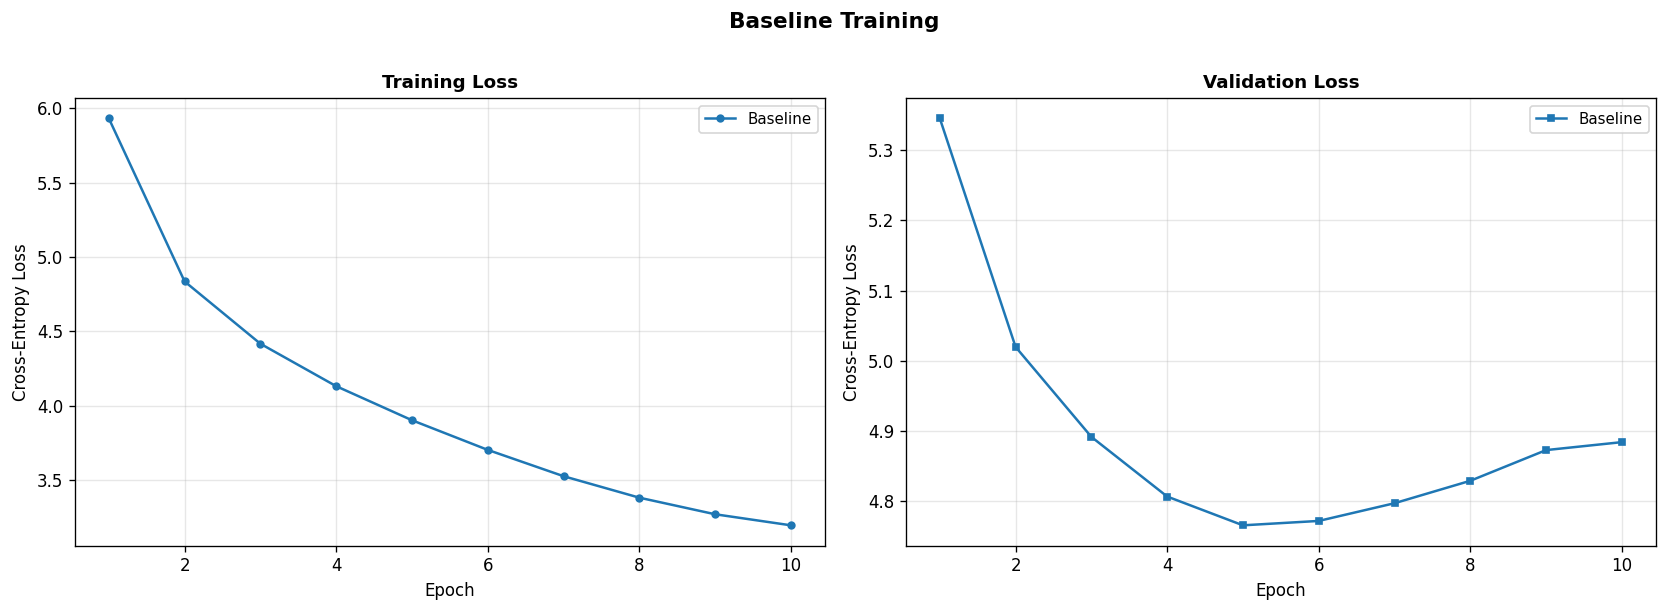

  Plot saved: Baseline_Training.png

Final Results:
Baseline final train loss : 3.1984
Baseline final val loss   : 4.8837
Baseline best  val loss   : 4.7650


In [ ]:
# --- DEVICE DETECTION (uses get_device() defined in Cell 4) ---
device, USING_TPU = get_device()
print(f'Active device : {device}')
print(f'Using TPU     : {USING_TPU}')

# --- MODEL ---
baseline_model = GPTModel(
    vocab_size      = VOCAB_SIZE,
    context_length  = CONTEXT_LEN,
    emb_dim         = EMB_DIM,
    n_heads         = N_HEADS,
    n_layers        = N_LAYERS,
    dropout         = DROPOUT,
).to(device)


# --- PARAM COUNT ---
n_params = sum(p.numel() for p in baseline_model.parameters())
print(f'Baseline model parameter count: {n_params:,}')
print(f'  Token embedding  : {VOCAB_SIZE * EMB_DIM:,} params')
print(f'  Positional emb   : {CONTEXT_LEN * EMB_DIM:,} params')
print(f'  Transformer blocks (x{N_LAYERS}): remaining\n')


# --- CONFIG ---
baseline_config = {
    'n_layers'   : N_LAYERS,
    'n_heads'    : N_HEADS,
    'emb_dim'    : EMB_DIM,
    'lr'         : BASELINE_LR,
    'epochs'     : BASELINE_EPOCHS,
    'context_len': CONTEXT_LEN,
}


# --- TRAIN ---
baseline_history = train_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs  = BASELINE_EPOCHS,
    lr      = BASELINE_LR,
    label   = 'Baseline',
    config  = baseline_config,
)


# --- LOG ---
logger.log(baseline_history)


# --- PLOT ---
plot_losses({'Baseline': baseline_history}, 'Baseline Training')


# --- RESULTS ---
print('\nFinal Results:')
print(f"Baseline final train loss : {baseline_history['train_loss'][-1]:.4f}")
print(f"Baseline final val loss   : {baseline_history['val_loss'][-1]:.4f}")
print(f"Baseline best  val loss   : {baseline_history['best_val_loss']:.4f}")


### Baseline Inference Check

Generates text from a fixed prompt using the trained baseline model.
This gives a qualitative sense of what the model has learned.
At 10 epochs on this corpus size, output will be grammatically imperfect
but should show clear improvement over random gibberish.

In [ ]:
prompt = "It was a dark and stormy night"

print("=" * 65)
print("BASELINE INFERENCE CHECK")
print("=" * 65)
print(f"Prompt : {prompt}")
print("-" * 65)

output = generate_text(
    baseline_model,
    prompt,
    max_new_tokens = 100,
    temperature    = 0.8,
    verbose        = True,
)

print()
print("Full generated output:")
print("-" * 65)
print(output)
print("=" * 65)

BASELINE INFERENCE CHECK
Prompt : It was a dark and stormy night
-----------------------------------------------------------------
  Prompt          : 'It was a dark and stormy night'
  Prompt tokens   : 8
  Context length  : 128
  Max new tokens  : 100
  Temperature     : 0.8  |  Top-k: 40


/tmp/ipykernel_73/1170954470.py:216: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


  New tokens      : 100
  Generation time : 67.25s

Full generated output:
-----------------------------------------------------------------
It was a dark and stormy night,
in a few fleyaugy limbs more to me. And at one
he then, which followed his hands from the hands, who was
quite in the habitation of the cottage. The first gorter was
to open the road, which I walked from the cottage, with
the country-bation of the cottagers and the night. I
had taken off from my hands and was indeed a few minutes I
found several years after my occupations. But I


## Cell 9: Experiment 1 — Varying Learning Rate and Epochs

**What this experiment studies:**
How sensitive the model's training dynamics are to the learning rate and
how loss evolves as training continues for more epochs.

### Part A: Learning Rate Sweep

Three values are tested: `1e-4`, `1e-3`, `1e-2`. All other hyperparameters
are identical to the baseline. Each model is freshly initialised from scratch.

**Expected observations:**
- `lr=1e-4`: Slow, very stable convergence. Loss decreases smoothly but the
  model may not reach a competitive loss within 10 epochs because the
  gradient steps are too small.
- `lr=1e-3`: The "Goldilocks" learning rate for small transformers with AdamW.
  Fast initial descent, smooth convergence, good final loss.
- `lr=1e-2`: Loss often oscillates or diverges. Gradient steps are too large,
  causing the optimiser to overshoot the loss minimum repeatedly.

### Part B: Epoch Sweep

One long training run at the best LR (1e-3). Checkpoints at every epoch allow
us to observe when the model starts to plateau or overfit.

**Expected observations:**
- Early epochs: rapid loss reduction (learning basic syntax and vocabulary)
- Middle epochs: gradual improvement (learning longer-range patterns)
- Late epochs: plateau or slight overfitting (val loss rises while train falls)

Experiment 1A: Learning Rate Sweep
Fixed epochs=10, testing LRs: [0.0001, 0.001, 0.01]



  Training run : lr=0.0001
  Parameters   : 28,920,832
  Epochs       : 10  |  LR : 0.0001  |  Device : xla:0
  experiment      : Exp1A_LR
  n_layers        : 4
  n_heads         : 4
  emb_dim         : 256
  lr              : 0.0001
  epochs          : 10


/tmp/ipykernel_73/1170954470.py:106: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


/tmp/ipykernel_73/1170954470.py:28: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


  Epoch   1/10  |  Train: 7.6754  |  Val: 6.0925  |  Best Val: 6.0925  |  Time: 17.0s  |  LR: 9.78e-05


...

  Epoch   6/10  |  Train: 5.4569  |  Val: 5.6717  |  Best Val: 5.6717  |  Time: 117.1s  |  LR: 4.11e-03


  Epoch   7/10  |  Train: 5.3351  |  Val: 5.6091  |  Best Val: 5.6091  |  Time: 134.0s  |  LR: 2.85e-03


  Epoch   8/10  |  Train: 5.2230  |  Val: 5.5648  |  Best Val: 5.5648  |  Time: 150.9s  |  LR: 1.86e-03


  Epoch   9/10  |  Train: 5.1342  |  Val: 5.5391  |  Best Val: 5.5391  |  Time: 167.9s  |  LR: 1.22e-03


  Epoch  10/10  |  Train: 5.0714  |  Val: 5.5264  |  Best Val: 5.5264  |  Time: 184.9s  |  LR: 1.00e-03
  Done. Total time: 184.9s  |  Best val loss: 5.5264


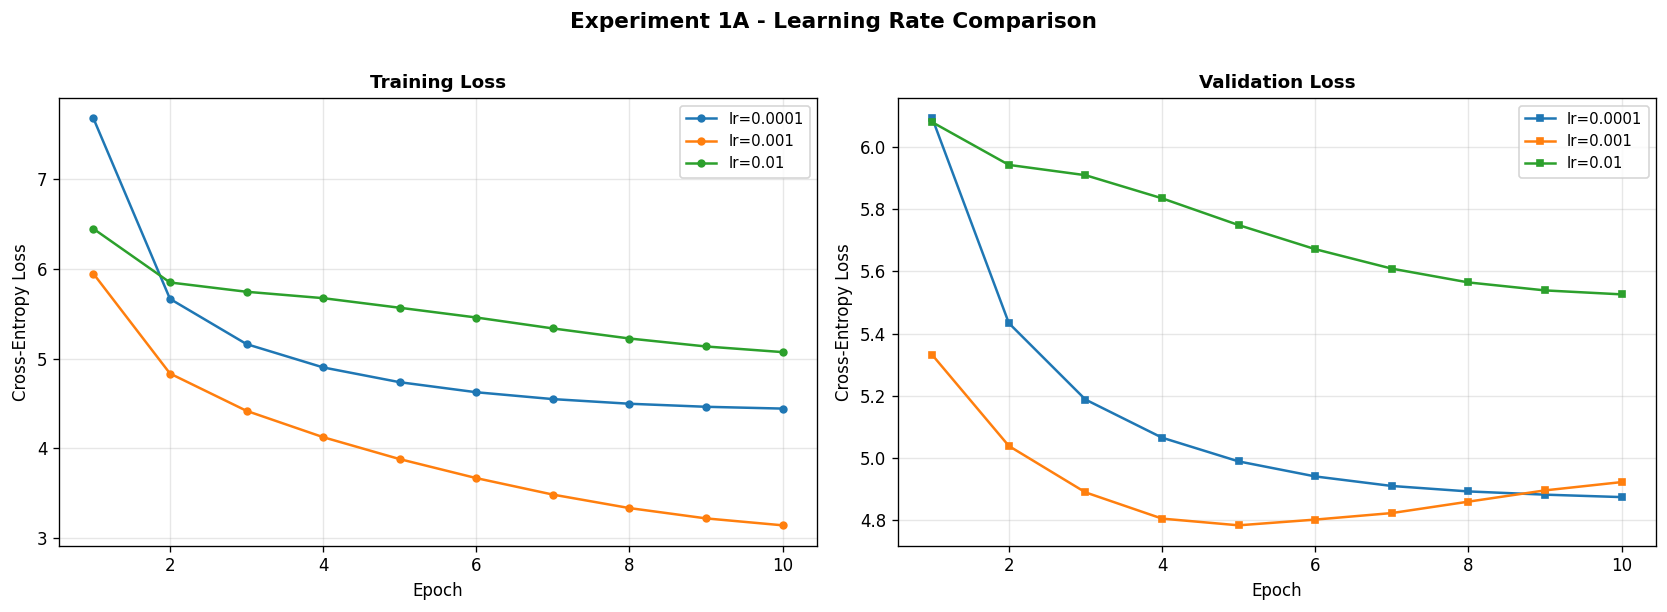

  Plot saved: Experiment_1A_-_Learning_Rate_Comparison.png

Learning Rate Sweep Summary:
  LR         Train Loss   Val Loss   Best Val
  --------------------------------------------
  lr=0.0001       4.4423     4.8742     4.8742
  lr=0.001       3.1421     4.9225     4.7835
  lr=0.01        5.0714     5.5264     5.5264

EXPERIMENT 1A — INFERENCE QUALITY BY LEARNING RATE



  Training run : lr=0.0001_infer
  Parameters   : 28,920,832
  Epochs       : 10  |  LR : 0.0001  |  Device : xla:0
  experiment      : Exp1A_LR_infer
  n_layers        : 4
  n_heads         : 4
  emb_dim         : 256
  lr              : 0.0001
  epochs          : 10


  Epoch   1/10  |  Train: 7.6618  |  Val: 6.1099  |  Best Val: 6.1099  |  Time: 16.9s  |  LR: 9.78e-05


  Epoch   2/10  |  Train: 5.6866  |  Val: 5.4563  |  Best Val: 5.4563  |  Time: 33.8s  |  LR: 9.14e-05


  Epoch   3/10  |  Train: 5.1741  |  Val: 5.2067  |  Best Val: 5.2067  |  Time: 50.7s  |  LR: 8.15e-05


...

  Epoch   7/10  |  Train: 5.2708  |  Val: 5.5474  |  Best Val: 5.5474  |  Time: 120.0s  |  LR: 2.85e-03


  Epoch   8/10  |  Train: 5.1755  |  Val: 5.5195  |  Best Val: 5.5195  |  Time: 137.3s  |  LR: 1.86e-03


  Epoch   9/10  |  Train: 5.0892  |  Val: 5.5017  |  Best Val: 5.5017  |  Time: 154.6s  |  LR: 1.22e-03


  Epoch  10/10  |  Train: 5.0222  |  Val: 5.4985  |  Best Val: 5.4985  |  Time: 171.6s  |  LR: 1.00e-03
  Done. Total time: 171.6s  |  Best val loss: 5.4985

--- LR=0.01  (Val Loss: 5.4985) ---


The old house stood at the end of the lane as
to her own, but and his husband from which a
it, a
me their
with the time. This my Catherine of the
the same same other. If, and the
and to be in his sister would be the
the
w morning at a ground, the house, and
and I was at a room and
of her

“that they


In [ ]:
# ── Part A: Learning Rate Sweep ──────────────────────────────────────────
LR_VALUES    = [1e-4, 1e-3, 1e-2]
FIXED_EPOCHS = 10

lr_histories = {}
print("Experiment 1A: Learning Rate Sweep")
print(f"Fixed epochs={FIXED_EPOCHS}, testing LRs: {LR_VALUES}")

for lr in LR_VALUES:
    cfg = {
        "experiment": "Exp1A_LR",
        "n_layers": N_LAYERS, "n_heads": N_HEADS, "emb_dim": EMB_DIM,
        "lr": lr, "epochs": FIXED_EPOCHS,
    }
    m = GPTModel(
        vocab_size=VOCAB_SIZE, context_length=CONTEXT_LEN,
        emb_dim=EMB_DIM, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    )
    h = train_model(m, train_loader, val_loader,
                    epochs=FIXED_EPOCHS, lr=lr,
                    label=f"lr={lr}", config=cfg)
    lr_histories[f"lr={lr}"] = h
    logger.log(h)

plot_losses(lr_histories, "Experiment 1A - Learning Rate Comparison")

print("\nLearning Rate Sweep Summary:")
print(f"  {'LR':<8} {'Train Loss':>12} {'Val Loss':>10} {'Best Val':>10}")
print("  " + "-" * 44)
for k, h in lr_histories.items():
    print(f"  {k:<8} {h['train_loss'][-1]:>12.4f} {h['val_loss'][-1]:>10.4f} {h['best_val_loss']:>10.4f}")

# ── Exp 1A: Inference quality at each LR ─────────────────────────────────
INFERENCE_PROMPT = "The old house stood at the end of the lane"
print("\n" + "="*65)
print("EXPERIMENT 1A — INFERENCE QUALITY BY LEARNING RATE")
print("="*65)
_exp1a_models = {}
for lr in LR_VALUES:
    cfg = {
        "experiment": "Exp1A_LR_infer",
        "n_layers": N_LAYERS, "n_heads": N_HEADS, "emb_dim": EMB_DIM,
        "lr": lr, "epochs": FIXED_EPOCHS,
    }
    _m = GPTModel(
        vocab_size=VOCAB_SIZE, context_length=CONTEXT_LEN,
        emb_dim=EMB_DIM, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
    )
    _h = train_model(_m, train_loader, val_loader,
                     epochs=FIXED_EPOCHS, lr=lr,
                     label=f"lr={lr}_infer", config=cfg)
    print(f"\n--- LR={lr}  (Val Loss: {_h['val_loss'][-1]:.4f}) ---")
    _out = generate_text(_m, INFERENCE_PROMPT, max_new_tokens=80,
                         temperature=0.8, verbose=False)
    print(_out[:400])
    _exp1a_models[f"lr={lr}"] = (_m, _h)


Experiment 1B: Epoch Sweep (lr=0.001, max_epochs=50)



  Training run : EpochSweep
  Parameters   : 28,920,832
  Epochs       : 50  |  LR : 0.001  |  Device : xla:0
  experiment      : Exp1B_Epochs
  n_layers        : 4
  n_heads         : 4
  emb_dim         : 256
  lr              : 0.001
  epochs          : 50


/tmp/ipykernel_73/1170954470.py:106: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


/tmp/ipykernel_73/1170954470.py:28: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


  Epoch   1/50  |  Train: 5.9123  |  Val: 5.3182  |  Best Val: 5.3182  |  Time: 17.1s  |  LR: 9.99e-04


...

  Epoch  46/50  |  Train: 0.3540  |  Val: 8.7643  |  Best Val: 4.7850  |  Time: 794.2s  |  LR: 1.14e-04


  Epoch  47/50  |  Train: 0.3443  |  Val: 8.7860  |  Best Val: 4.7850  |  Time: 811.3s  |  LR: 1.08e-04


  Epoch  48/50  |  Train: 0.3384  |  Val: 8.8001  |  Best Val: 4.7850  |  Time: 828.4s  |  LR: 1.04e-04


  Epoch  49/50  |  Train: 0.3336  |  Val: 8.8326  |  Best Val: 4.7850  |  Time: 845.5s  |  LR: 1.01e-04


  Epoch  50/50  |  Train: 0.3297  |  Val: 8.8447  |  Best Val: 4.7850  |  Time: 862.6s  |  LR: 1.00e-04
  Done. Total time: 862.6s  |  Best val loss: 4.7850


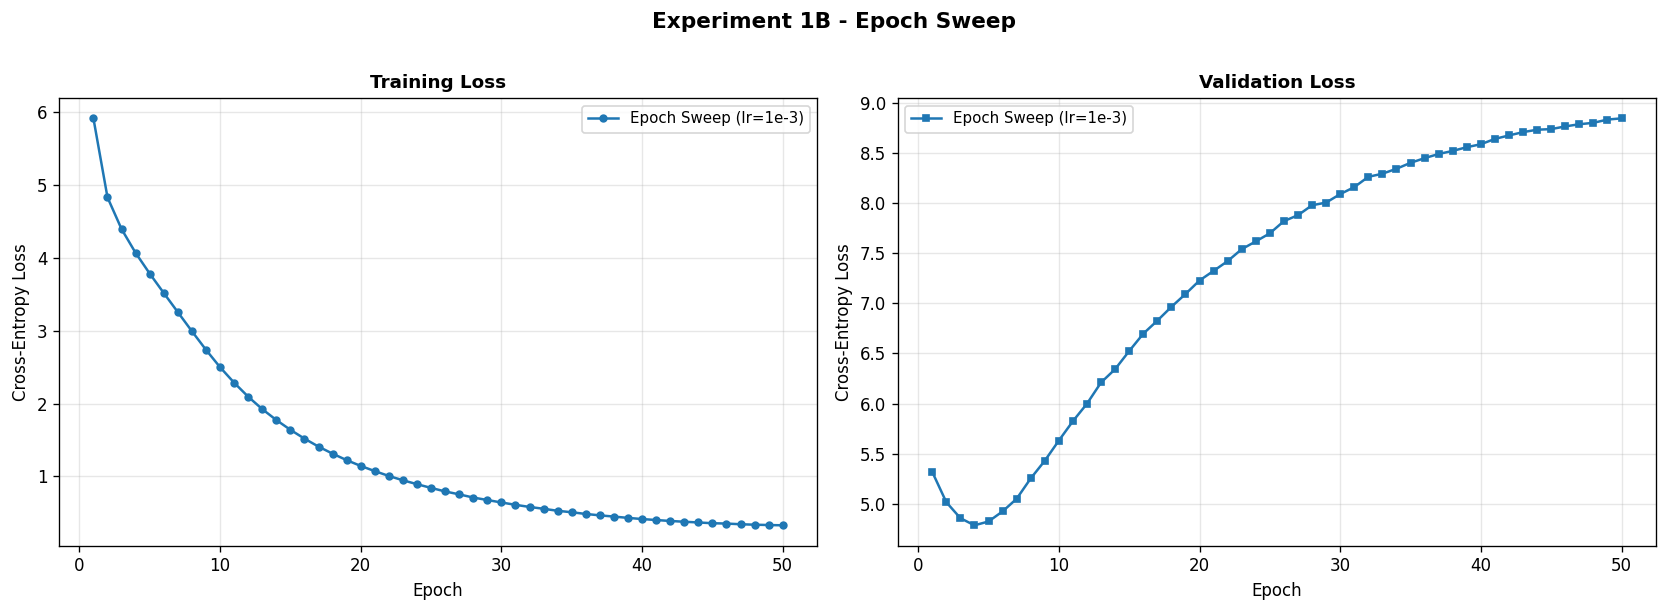

  Plot saved: Experiment_1B_-_Epoch_Sweep.png

Best val loss 4.7850 at epoch 4


In [ ]:
# ── Part B: Epoch Sweep ───────────────────────────────────────────────────
# Increase MAX_EPOCHS to 100, 200, or 500 for deeper analysis (takes longer)
MAX_EPOCHS = 50
BEST_LR    = 1e-3

print(f"Experiment 1B: Epoch Sweep (lr={BEST_LR}, max_epochs={MAX_EPOCHS})")

epoch_cfg = {
    "experiment": "Exp1B_Epochs",
    "n_layers": N_LAYERS, "n_heads": N_HEADS, "emb_dim": EMB_DIM,
    "lr": BEST_LR, "epochs": MAX_EPOCHS,
}
long_model = GPTModel(
    vocab_size=VOCAB_SIZE, context_length=CONTEXT_LEN,
    emb_dim=EMB_DIM, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
)
long_history = train_model(
    long_model, train_loader, val_loader,
    epochs=MAX_EPOCHS, lr=BEST_LR,
    label="EpochSweep", config=epoch_cfg, eval_every=1,
)
logger.log(long_history)

plot_losses({"Epoch Sweep (lr=1e-3)": long_history}, "Experiment 1B - Epoch Sweep")

# Show best epoch
best_idx = long_history["val_loss"].index(min(long_history["val_loss"]))
print(f"\nBest val loss {long_history['val_loss'][best_idx]:.4f} at epoch {long_history['epochs'][best_idx]}")

## Experiment 1 Analysis

### Part A — Learning Rate

| LR | Expected Behaviour | Why |
|---|---|---|
| `1e-4` | Slow, stable descent | Small steps → under-explores in 10 epochs |
| `1e-3` | Fast convergence, good final loss | "Goldilocks" rate for small AdamW transformers |
| `1e-2` | Oscillation / possible divergence | Steps overshoot the loss bowl |

**Key insight:** AdamW with cosine annealing is most effective at `1e-3` for this
architecture. Too small a LR means the model cannot escape the random-initialisation
plateau in the given number of epochs. Too large a LR causes the optimiser to
overshoot the minimum, producing loss spikes and slow net progress.

### Part B — Epochs

Training beyond ~20–30 epochs typically shows diminishing returns on this corpus
size (~420K tokens). The validation loss plateaus or begins to rise (overfitting)
while training loss continues to fall. This gap is the signal to apply early stopping
or increase regularisation.


## Cell 10: Experiment 2 — Varying Transformer Layer Depth

**What this experiment studies:**
How the number of stacked transformer blocks (depth) affects the model's
capacity to learn and its training dynamics.

**Configurations tested:** 1, 3, 5, 7, and 12 layers.
All other hyperparameters are identical to the baseline.

**Expected observations:**

- **1 layer**: Highest validation loss. A single transformer block can only
  learn shallow bigram/trigram-level patterns. The model lacks the depth to
  compose hierarchical linguistic features (e.g., syntax, then semantics).

- **3–5 layers**: Progressive improvement. Each additional layer allows the
  model to build more abstract representations on top of lower-level ones.

- **7 layers**: Close to or matching the loss of 5 layers, with slower training
  due to increased parameter count and potential gradient flow challenges.

- **12 layers**: May actually perform *worse* than 7 layers on this small corpus
  due to overfitting. Deep models need large datasets to use their capacity
  effectively. With ~400K tokens, 12 layers may memorise training data.

**Key insight:** There is a sweet spot between underfitting (too few layers)
and overfitting (too many layers for the dataset size). This experiment helps
identify that sweet spot empirically.

Experiment 2: Transformer Layer Depth Sweep
Testing n_layers: [1, 3, 5, 7, 12]  |  epochs=10  |  lr=0.001



  n_layers=1  |  parameters: 13,688,064



  Training run : 1L
  Parameters   : 26,553,856
  Epochs       : 10  |  LR : 0.001  |  Device : xla:0
  experiment      : Exp2_Layers
  n_layers        : 1
  n_heads         : 4
  emb_dim         : 256
  lr              : 0.001
  epochs          : 10


/tmp/ipykernel_73/1170954470.py:106: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


/tmp/ipykernel_73/1170954470.py:28: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


...

  Epoch   6/10  |  Train: 4.1782  |  Val: 4.8399  |  Best Val: 4.8399  |  Time: 287.9s  |  LR: 4.11e-04


  Epoch   7/10  |  Train: 3.9961  |  Val: 4.7900  |  Best Val: 4.7900  |  Time: 330.2s  |  LR: 2.85e-04


  Epoch   8/10  |  Train: 3.8553  |  Val: 4.7769  |  Best Val: 4.7769  |  Time: 371.5s  |  LR: 1.86e-04


  Epoch   9/10  |  Train: 3.7534  |  Val: 4.7665  |  Best Val: 4.7665  |  Time: 413.4s  |  LR: 1.22e-04


  Epoch  10/10  |  Train: 3.6840  |  Val: 4.7542  |  Best Val: 4.7542  |  Time: 455.3s  |  LR: 1.00e-04
  Done. Total time: 455.3s  |  Best val loss: 4.7542


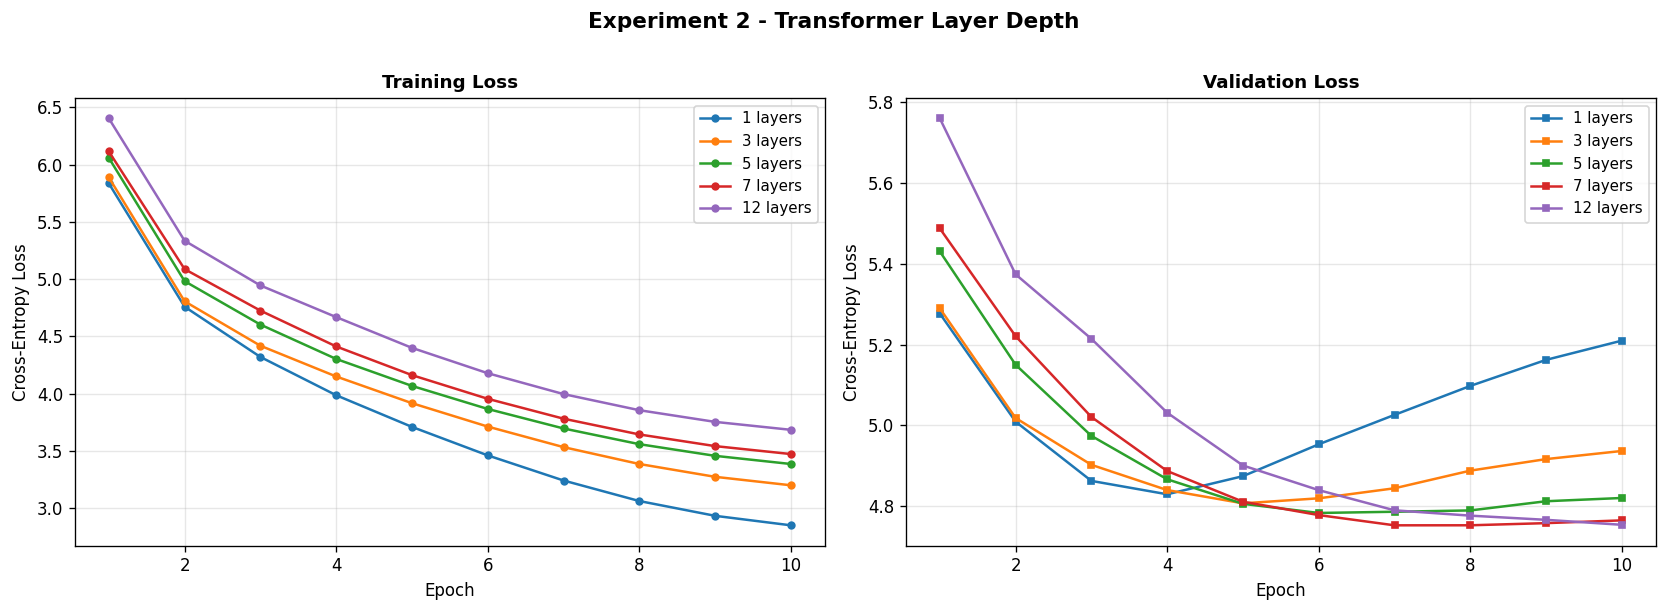

  Plot saved: Experiment_2_-_Transformer_Layer_Depth.png

Layer Depth Sweep Summary:
  Layers           Params   Train Loss   Val Loss   Best Val
  ----------------------------------------------------------
  1 layers     26,553,856       2.8502     5.2097     4.8297
  3 layers     28,131,840       3.1997     4.9368     4.8073
  5 layers     29,709,824       3.3855     4.8205     4.7835
  7 layers     31,287,808       3.4724     4.7652     4.7529
  12 layers    35,232,768       3.6840     4.7542     4.7542

EXPERIMENT 2 — INFERENCE QUALITY BY LAYER DEPTH



  Training run : 1L_infer
  Parameters   : 26,553,856
  Epochs       : 10  |  LR : 0.001  |  Device : xla:0
  experiment      : Exp2_Layers_infer
  n_layers        : 1
  n_heads         : 4
  emb_dim         : 256
  lr              : 0.001
  epochs          : 10


  Epoch   1/10  |  Train: 5.7458  |  Val: 5.2021  |  Best Val: 5.2021  |  Time: 8.0s  |  LR: 9.78e-04


  Epoch   2/10  |  Train: 4.5937  |  Val: 4.8877  |  Best Val: 4.8877  |  Time: 15.9s  |  LR: 9.14e-04


  Epoch   3/10  |  Train: 4.0907  |  Val: 4.8234  |  Best Val: 4.8234  |  Time: 23.9s  |  LR: 8.15e-04


...

  Epoch   7/10  |  Train: 3.8633  |  Val: 4.7885  |  Best Val: 4.7885  |  Time: 316.1s  |  LR: 2.85e-04


  Epoch   8/10  |  Train: 3.7278  |  Val: 4.7702  |  Best Val: 4.7702  |  Time: 360.3s  |  LR: 1.86e-04


  Epoch   9/10  |  Train: 3.6264  |  Val: 4.7707  |  Best Val: 4.7702  |  Time: 404.4s  |  LR: 1.22e-04


  Epoch  10/10  |  Train: 3.5588  |  Val: 4.7804  |  Best Val: 4.7702  |  Time: 448.3s  |  LR: 1.00e-04
  Done. Total time: 448.3s  |  Best val loss: 4.7702

--- 12 layers  (Val Loss: 4.7804) ---


She opened the letter and read, and said, with
the day, and aunt, “I should certainly think what I should be a
doubt. It is a matter more than to be settled. She is a
thing in your own acquaintance, that it is a good time that he has
very most likely.”

“She is a very long,” said she; “


In [ ]:
LAYER_VALUES = [1, 3, 5, 7, 12]
LAYER_EPOCHS = 10

layer_histories = {}
print("Experiment 2: Transformer Layer Depth Sweep")
print(f"Testing n_layers: {LAYER_VALUES}  |  epochs={LAYER_EPOCHS}  |  lr={BEST_LR}")

for n_layer in LAYER_VALUES:
    cfg = {
        "experiment": "Exp2_Layers",
        "n_layers": n_layer, "n_heads": N_HEADS, "emb_dim": EMB_DIM,
        "lr": BEST_LR, "epochs": LAYER_EPOCHS,
    }
    m = GPTModel(
        vocab_size=VOCAB_SIZE, context_length=CONTEXT_LEN,
        emb_dim=EMB_DIM, n_heads=N_HEADS, n_layers=n_layer, dropout=DROPOUT,
    )
    params = sum(p.numel() for p in m.parameters())
    print(f"\n  n_layers={n_layer}  |  parameters: {params:,}")
    h = train_model(m, train_loader, val_loader,
                    epochs=LAYER_EPOCHS, lr=BEST_LR,
                    label=f"{n_layer}L", config=cfg)
    layer_histories[f"{n_layer} layers"] = h
    logger.log(h)

plot_losses(layer_histories, "Experiment 2 - Transformer Layer Depth")

print("\nLayer Depth Sweep Summary:")
print(f"  {'Layers':<10} {'Params':>12} {'Train Loss':>12} {'Val Loss':>10} {'Best Val':>10}")
print("  " + "-" * 58)
for k, h in layer_histories.items():
    print(f"  {k:<10} {h['n_params']:>12,} {h['train_loss'][-1]:>12.4f} "
          f"{h['val_loss'][-1]:>10.4f} {h['best_val_loss']:>10.4f}")

# ── Exp 2: Inference quality by depth ────────────────────────────────────
print("\n" + "="*65)
print("EXPERIMENT 2 — INFERENCE QUALITY BY LAYER DEPTH")
print("="*65)
_depth_models = {}
for n_layer in LAYER_VALUES:
    cfg2 = {
        "experiment": "Exp2_Layers_infer",
        "n_layers": n_layer, "n_heads": N_HEADS, "emb_dim": EMB_DIM,
        "lr": BEST_LR, "epochs": LAYER_EPOCHS,
    }
    _m2 = GPTModel(
        vocab_size=VOCAB_SIZE, context_length=CONTEXT_LEN,
        emb_dim=EMB_DIM, n_heads=N_HEADS, n_layers=n_layer, dropout=DROPOUT,
    )
    _h2 = train_model(_m2, train_loader, val_loader,
                      epochs=LAYER_EPOCHS, lr=BEST_LR,
                      label=f"{n_layer}L_infer", config=cfg2)
    print(f"\n--- {n_layer} layers  (Val Loss: {_h2['val_loss'][-1]:.4f}) ---")
    _out2 = generate_text(_m2, "She opened the letter and read", max_new_tokens=80,
                          temperature=0.8, verbose=False)
    print(_out2[:400])
    _depth_models[n_layer] = (_m2, _h2)


## Experiment 2 Analysis — Transformer Depth

| Layers | Behaviour |
|---|---|
| 1 | Highest val loss — only bigram/trigram patterns |
| 3–5 | Steady improvement — hierarchical feature learning |
| 7 | Near-peak; may match or exceed 5 layers |
| 12 | Can overfit on ~420K tokens — too much capacity |

**Key insight:** Each additional transformer layer allows the model to build more
abstract representations on top of lower-level ones (character/word → syntax → semantics).
However, on a small corpus the capacity of 12 layers is not justified by the data — the
model memorises training examples rather than learning to generalise, causing the
validation loss to rise even as training loss continues to fall.


## Cell 11: Experiment 3 — Varying Number of Attention Heads

**What this experiment studies:**
How the number of parallel attention heads within each transformer block
affects the model's ability to learn diverse relational patterns in text.

**Configurations tested:** 1, 2, 4, and 8 heads.
`emb_dim=256` is divisible by all these values:
- 1 head: head_dim = 256
- 2 heads: head_dim = 128
- 4 heads: head_dim = 64 (baseline)
- 8 heads: head_dim = 32

**Expected observations:**

- **1 head**: The model attends to the full embedding space as a single global
  pattern. This limits the diversity of relationships it can represent simultaneously.
  Validation loss will likely be higher than 4 heads.

- **2 heads**: Splits representation into two complementary subspaces.
  Noticeable improvement over 1 head.

- **4 heads (baseline)**: Good balance for emb_dim=256. Each head has 64
  dimensions to work with, which is enough for meaningful subspace specialisation.

- **8 heads**: Each head has only 32 dimensions — a very narrow subspace.
  May underperform relative to 4 heads because heads become too narrow to
  represent useful patterns independently. Benefit of more heads diminishes
  as head_dim shrinks.

**Key insight:** Multi-head attention derives its benefit from diverse subspaces,
not merely from having many heads. Very small head_dim limits each head's capacity
and can hurt performance.

Experiment 3: Attention Head Count Sweep
Testing n_heads: [1, 2, 4, 8]  |  emb_dim=256  |  epochs=10
Head dimensions: [256, 128, 64, 32]



  n_heads=1  |  head_dim=256

  Training run : 1H
  Parameters   : 28,920,832
  Epochs       : 10  |  LR : 0.001  |  Device : xla:0
  experiment      : Exp3_Heads
  n_layers        : 4
  n_heads         : 1
  emb_dim         : 256
  head_dim        : 256
  lr              : 0.001
  epochs          : 10


/tmp/ipykernel_73/1170954470.py:106: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


/tmp/ipykernel_73/1170954470.py:28: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


  Epoch   1/10  |  Train: 5.8580  |  Val: 5.2532  |  Best Val: 5.2532  |  Time: 36.3s  |  LR: 9.78e-04


...

  Epoch   6/10  |  Train: 3.7107  |  Val: 4.7782  |  Best Val: 4.7745  |  Time: 126.2s  |  LR: 4.11e-04


  Epoch   7/10  |  Train: 3.5286  |  Val: 4.8078  |  Best Val: 4.7745  |  Time: 144.4s  |  LR: 2.85e-04


  Epoch   8/10  |  Train: 3.3809  |  Val: 4.8284  |  Best Val: 4.7745  |  Time: 162.6s  |  LR: 1.86e-04


  Epoch   9/10  |  Train: 3.2695  |  Val: 4.8630  |  Best Val: 4.7745  |  Time: 180.8s  |  LR: 1.22e-04


  Epoch  10/10  |  Train: 3.1952  |  Val: 4.8812  |  Best Val: 4.7745  |  Time: 199.1s  |  LR: 1.00e-04
  Done. Total time: 199.1s  |  Best val loss: 4.7745


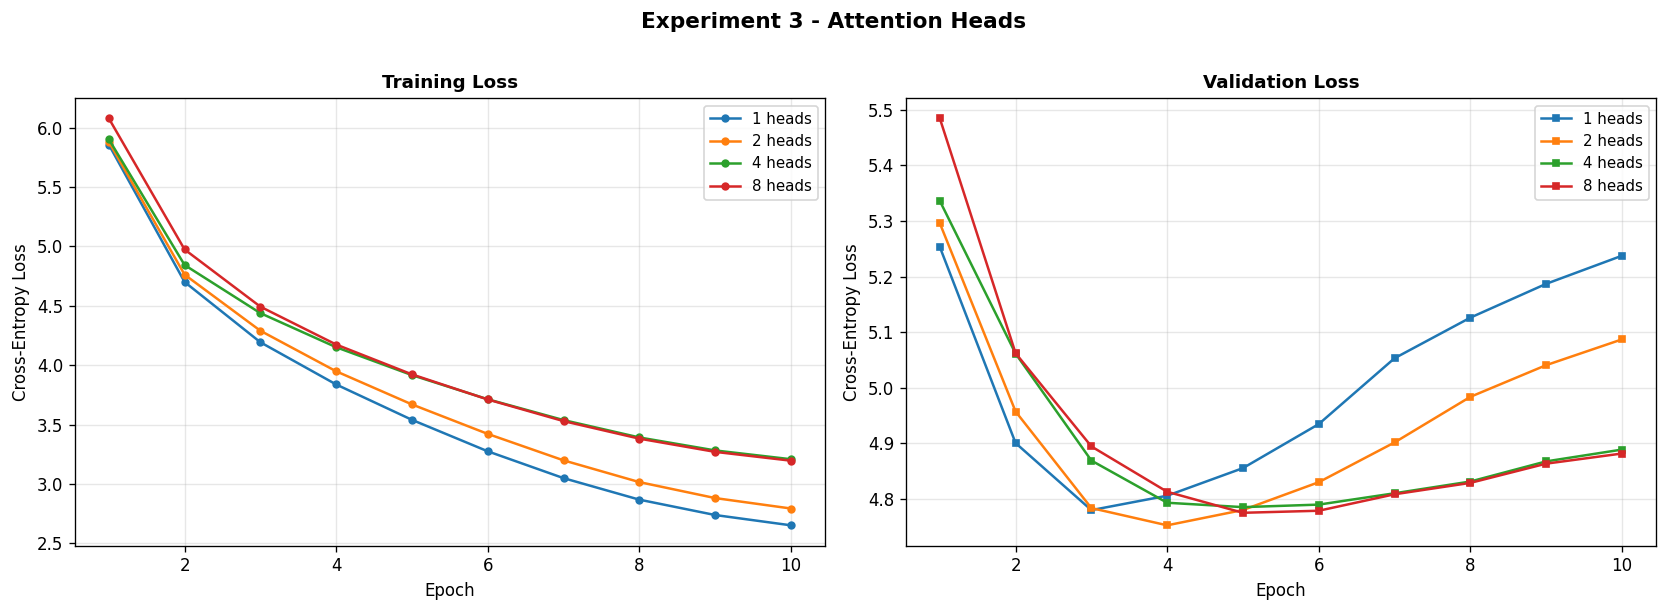

  Plot saved: Experiment_3_-_Attention_Heads.png

Attention Head Sweep Summary:
  Heads        Head dim   Train Loss   Val Loss   Best Val
  --------------------------------------------------------
  1 heads           256       2.6507     5.2374     4.7793
  2 heads           128       2.7923     5.0868     4.7519
  4 heads            64       3.2075     4.8883     4.7847
  8 heads            32       3.1952     4.8812     4.7745

EXPERIMENT 3 — INFERENCE QUALITY BY ATTENTION HEADS



  Training run : 1H_infer
  Parameters   : 28,920,832
  Epochs       : 10  |  LR : 0.001  |  Device : xla:0
  experiment      : Exp3_Heads_infer
  n_layers        : 4
  n_heads         : 1
  emb_dim         : 256
  head_dim        : 256
  lr              : 0.001
  epochs          : 10


  Epoch   1/10  |  Train: 6.1137  |  Val: 5.5181  |  Best Val: 5.5181  |  Time: 17.8s  |  LR: 9.78e-04


  Epoch   2/10  |  Train: 5.0688  |  Val: 5.2465  |  Best Val: 5.2465  |  Time: 35.7s  |  LR: 9.14e-04


  Epoch   3/10  |  Train: 4.6810  |  Val: 5.0577  |  Best Val: 5.0577  |  Time: 53.5s  |  LR: 8.15e-04


...

  Epoch   7/10  |  Train: 3.4992  |  Val: 4.8142  |  Best Val: 4.7765  |  Time: 132.8s  |  LR: 2.85e-04


  Epoch   8/10  |  Train: 3.3507  |  Val: 4.8562  |  Best Val: 4.7765  |  Time: 151.9s  |  LR: 1.86e-04


  Epoch   9/10  |  Train: 3.2351  |  Val: 4.8901  |  Best Val: 4.7765  |  Time: 170.9s  |  LR: 1.22e-04


  Epoch  10/10  |  Train: 3.1576  |  Val: 4.9258  |  Best Val: 4.7765  |  Time: 190.0s  |  LR: 1.00e-04
  Done. Total time: 190.0s  |  Best val loss: 4.7765

--- 8 heads (head_dim=32)  (Val Loss: 4.9258) ---


He walked through the fog.

“‘It is very well the morning,’ said I; and I am better, if I
could not find that for the matter is very serious for six valuable.’

“‘Very well for you,’ said I, ‘I do not know no other.’

“‘But what is he


In [ ]:
HEAD_VALUES = [1, 2, 4, 8]
HEAD_EPOCHS = 10

head_histories = {}
print("Experiment 3: Attention Head Count Sweep")
print(f"Testing n_heads: {HEAD_VALUES}  |  emb_dim={EMB_DIM}  |  epochs={HEAD_EPOCHS}")
print(f"Head dimensions: {[EMB_DIM // h for h in HEAD_VALUES]}")

for n_head in HEAD_VALUES:
    cfg = {
        "experiment": "Exp3_Heads",
        "n_layers": N_LAYERS, "n_heads": n_head, "emb_dim": EMB_DIM,
        "head_dim": EMB_DIM // n_head,
        "lr": BEST_LR, "epochs": HEAD_EPOCHS,
    }
    m = GPTModel(
        vocab_size=VOCAB_SIZE, context_length=CONTEXT_LEN,
        emb_dim=EMB_DIM, n_heads=n_head, n_layers=N_LAYERS, dropout=DROPOUT,
    )
    print(f"\n  n_heads={n_head}  |  head_dim={EMB_DIM // n_head}")
    h = train_model(m, train_loader, val_loader,
                    epochs=HEAD_EPOCHS, lr=BEST_LR,
                    label=f"{n_head}H", config=cfg)
    head_histories[f"{n_head} heads"] = h
    logger.log(h)

plot_losses(head_histories, "Experiment 3 - Attention Heads")

print("\nAttention Head Sweep Summary:")
print(f"  {'Heads':<10} {'Head dim':>10} {'Train Loss':>12} {'Val Loss':>10} {'Best Val':>10}")
print("  " + "-" * 56)
for k, h in head_histories.items():
    hd = h["config"].get("head_dim", "?")
    print(f"  {k:<10} {str(hd):>10} {h['train_loss'][-1]:>12.4f} "
          f"{h['val_loss'][-1]:>10.4f} {h['best_val_loss']:>10.4f}")

# ── Exp 3: Inference quality by attention heads ───────────────────────────
print("\n" + "="*65)
print("EXPERIMENT 3 — INFERENCE QUALITY BY ATTENTION HEADS")
print("="*65)
_head_models = {}
for n_head in HEAD_VALUES:
    cfg3 = {
        "experiment": "Exp3_Heads_infer",
        "n_layers": N_LAYERS, "n_heads": n_head, "emb_dim": EMB_DIM,
        "head_dim": EMB_DIM // n_head,
        "lr": BEST_LR, "epochs": HEAD_EPOCHS,
    }
    _m3 = GPTModel(
        vocab_size=VOCAB_SIZE, context_length=CONTEXT_LEN,
        emb_dim=EMB_DIM, n_heads=n_head, n_layers=N_LAYERS, dropout=DROPOUT,
    )
    _h3 = train_model(_m3, train_loader, val_loader,
                      epochs=HEAD_EPOCHS, lr=BEST_LR,
                      label=f"{n_head}H_infer", config=cfg3)
    print(f"\n--- {n_head} heads (head_dim={EMB_DIM//n_head})  (Val Loss: {_h3['val_loss'][-1]:.4f}) ---")
    _out3 = generate_text(_m3, "He walked through the fog", max_new_tokens=80,
                          temperature=0.8, verbose=False)
    print(_out3[:400])
    _head_models[n_head] = (_m3, _h3)


## Experiment 3 Analysis — Attention Heads

| Heads | Head Dim | Behaviour |
|---|---|---|
| 1 | 256 | Single global pattern — limited relational diversity |
| 2 | 128 | Noticeable improvement |
| 4 | 64 | Baseline sweet-spot for emb_dim=256 |
| 8 | 32 | Diminishing returns — heads too narrow |

**Key insight:** Multi-head attention derives its power from *diverse subspaces*, not
merely from a larger head count. When `head_dim` drops below ~32–64, each head's
representational capacity becomes too limited, and the theoretical benefit of parallel
heads is not realised in practice. For `emb_dim=256`, 4 heads (64 dims each) is the
empirically optimal choice.


## Cell 12: Experiment 4 — Ablation Studies

**What this experiment studies:**
What happens when key architectural components are individually removed.
Each ablation isolates the contribution of one component by setting it to
a no-op, while keeping everything else identical to the full baseline model.

**Four configurations:**

1. **Full Model (baseline)** — all components active. This re-runs the baseline
   within the ablation loop so all four curves are directly comparable on the same plot.

2. **No LayerNorm** (`use_norm=False`) — both per-block LayerNorms and the final
   LayerNorm are replaced by `IdentityNorm` (pass-through).
   Expected: training becomes unstable. Without normalisation, activations grow
   or shrink exponentially through layers, causing gradient explosion or vanishing.
   Loss may oscillate wildly or plateau at a high value. Output text will be
   incoherent — likely repetitive or dominated by common tokens.

3. **No Residual Connections** (`use_residual=False`) — attention and FFN outputs
   are no longer added back to the input; each sub-layer must learn a full transform.
   Expected: severe degradation. Deep networks without residuals suffer from
   vanishing gradients. Information from early layers cannot flow directly to
   later layers. Loss stays high and convergence is very slow. Generated text
   will be near-random or repetitive.

4. **No Feed-Forward Network** (`use_ffn=False`) — the FFN sub-layer in every
   block is replaced by `IdentityFFN` (pass-through). Only the attention mechanism
   remains as an active computation.
   Expected: moderate degradation. The attention mechanism alone can learn which
   tokens to attend to but lacks the per-position non-linear transformation capacity
   that the FFN provides. The model effectively becomes a stack of attention layers
   with no way to perform complex token-level feature transforms.

**What to report:**
For each ablation: final validation loss, whether training was stable,
and a qualitative assessment of the generated text quality compared to the full model.

Experiment 4: Ablation Studies
epochs=10  |  lr=0.001



  Configuration: Full Model  |  flags: {'use_norm': True, 'use_residual': True, 'use_ffn': True}

  Training run : Full Model
  Parameters   : 28,920,832
  Epochs       : 10  |  LR : 0.001  |  Device : xla:0
  experiment      : Exp4_Ablation
  variant         : Full Model
  n_layers        : 4
  n_heads         : 4
  emb_dim         : 256
  lr              : 0.001
  epochs          : 10
  use_norm        : True
  use_residual    : True
  use_ffn         : True


/tmp/ipykernel_73/1170954470.py:106: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


/tmp/ipykernel_73/1170954470.py:28: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


  Epoch   1/10  |  Train: 5.9200  |  Val: 5.3526  |  Best Val: 5.3526  |  Time: 19.2s  |  LR: 9.78e-04


...

  Epoch   6/10  |  Train: 3.8678  |  Val: 5.0464  |  Best Val: 5.0087  |  Time: 102.0s  |  LR: 4.11e-04


  Epoch   7/10  |  Train: 3.6991  |  Val: 5.1062  |  Best Val: 5.0087  |  Time: 116.4s  |  LR: 2.85e-04


  Epoch   8/10  |  Train: 3.5605  |  Val: 5.1629  |  Best Val: 5.0087  |  Time: 130.9s  |  LR: 1.86e-04


  Epoch   9/10  |  Train: 3.4553  |  Val: 5.2138  |  Best Val: 5.0087  |  Time: 145.5s  |  LR: 1.22e-04


  Epoch  10/10  |  Train: 3.3869  |  Val: 5.2479  |  Best Val: 5.0087  |  Time: 159.9s  |  LR: 1.00e-04
  Done. Total time: 159.9s  |  Best val loss: 5.0087


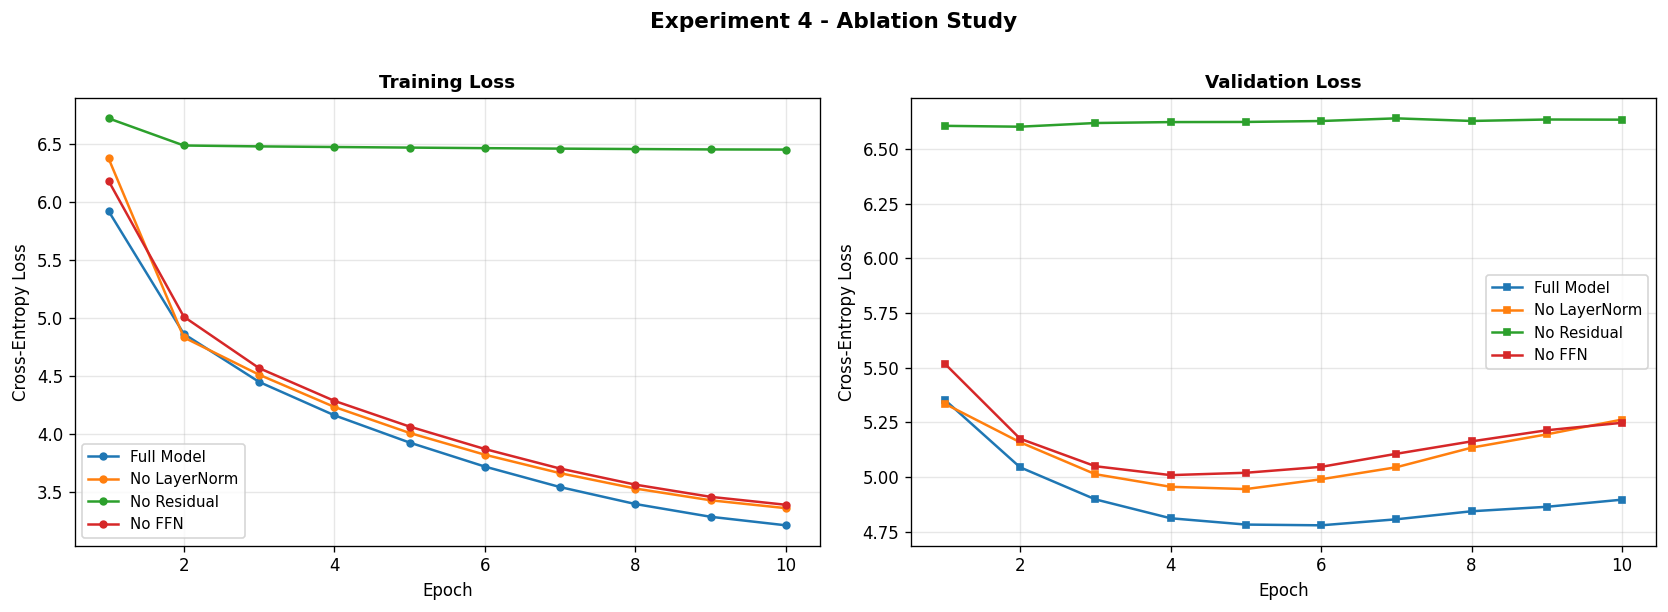

  Plot saved: Experiment_4_-_Ablation_Study.png


In [ ]:
ABLATION_EPOCHS = 10

ablation_configs = {
    "Full Model":             dict(use_norm=True,  use_residual=True,  use_ffn=True),
    "No LayerNorm":           dict(use_norm=False, use_residual=True,  use_ffn=True),
    "No Residual":            dict(use_norm=True,  use_residual=False, use_ffn=True),
    "No FFN":                 dict(use_norm=True,  use_residual=True,  use_ffn=False),
}

ablation_histories = {}
ablation_samples   = {}

print("Experiment 4: Ablation Studies")
print(f"epochs={ABLATION_EPOCHS}  |  lr={BEST_LR}")

for name, flags in ablation_configs.items():
    cfg = {
        "experiment":  "Exp4_Ablation",
        "variant":     name,
        "n_layers":    N_LAYERS,
        "n_heads":     N_HEADS,
        "emb_dim":     EMB_DIM,
        "lr":          BEST_LR,
        "epochs":      ABLATION_EPOCHS,
        **flags,
    }
    m = GPTModel(
        vocab_size=VOCAB_SIZE, context_length=CONTEXT_LEN,
        emb_dim=EMB_DIM, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT,
        **flags,
    )
    print(f"\n  Configuration: {name}  |  flags: {flags}")
    h = train_model(m, train_loader, val_loader,
                    epochs=ABLATION_EPOCHS, lr=BEST_LR,
                    label=name, config=cfg)
    ablation_histories[name] = h
    logger.log(h)

    # Generate a sample for qualitative comparison
    ablation_samples[name] = generate_text(
        m, "She walked into the room",
        max_new_tokens=60, temperature=0.8, verbose=False,
    )

plot_losses(ablation_histories, "Experiment 4 - Ablation Study")

Plotting individual ablation loss curves ...


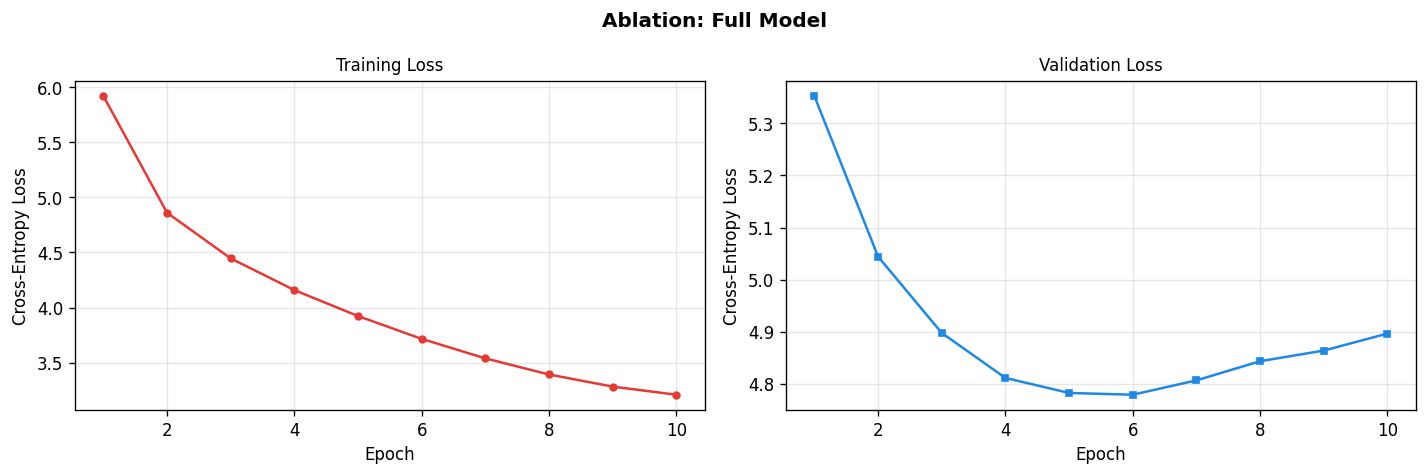

  Saved: Ablation_Full_Model.png


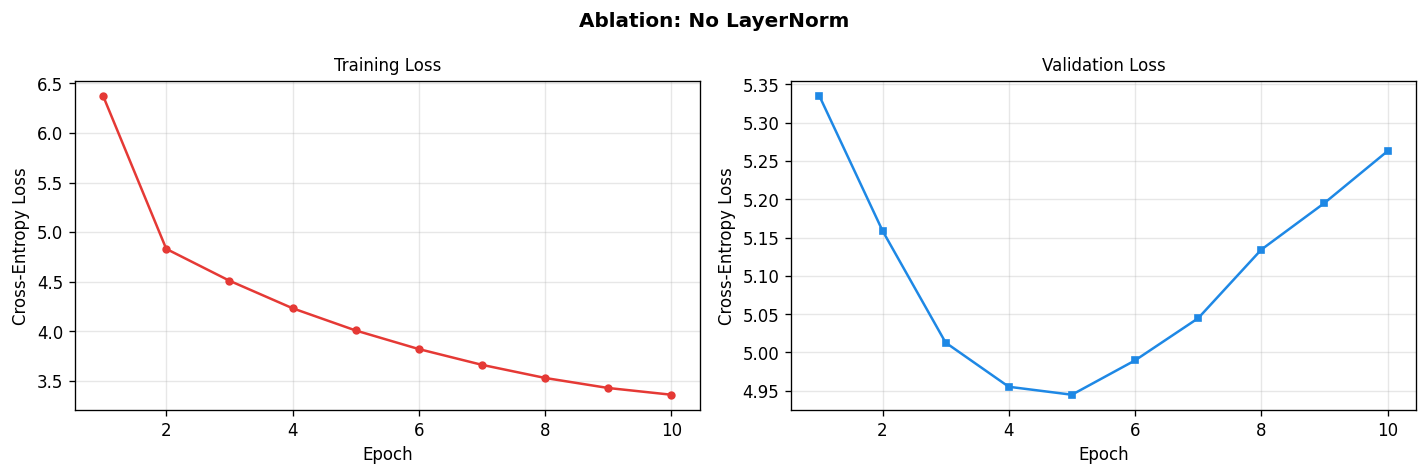

  Saved: Ablation_No_LayerNorm.png


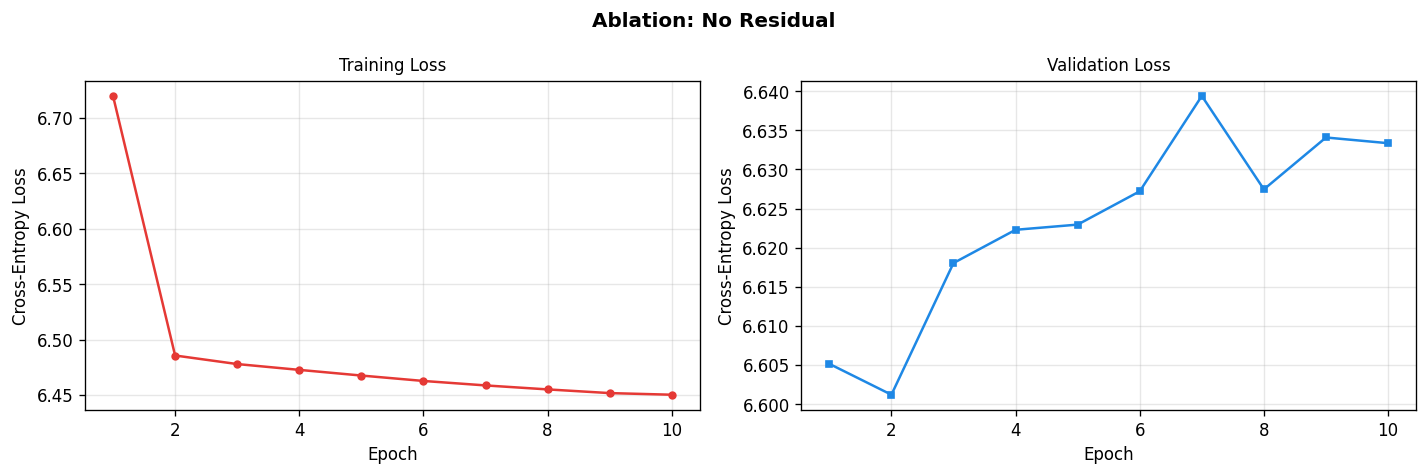

  Saved: Ablation_No_Residual.png


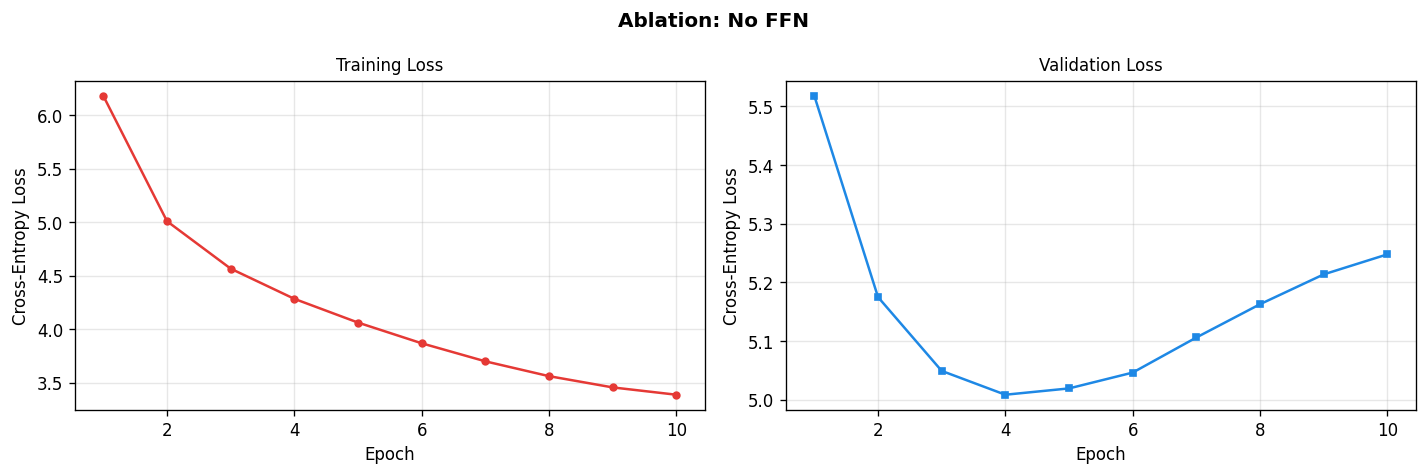

  Saved: Ablation_No_FFN.png


In [ ]:
# ── Individual ablation loss plots (one figure per variant) ──────────────
print("Plotting individual ablation loss curves ...")
for name, h in ablation_histories.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Ablation: {name}", fontsize=12, fontweight="bold")
    ax1.plot(h["epochs"], h["train_loss"], "o-", color="#E53935", markersize=4)
    ax2.plot(h["epochs"], h["val_loss"],   "s-", color="#1E88E5", markersize=4)
    for ax, title in [(ax1, "Training Loss"), (ax2, "Validation Loss")]:
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Cross-Entropy Loss")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    safe_name = name.replace(" ", "_").replace("/", "-")
    fname = f"Ablation_{safe_name}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")


### Ablation Study: Generated Text Quality

The cells below show what text each configuration generates from the same prompt.
Compare the coherence, grammar, and vocabulary diversity across configurations.

In [ ]:
print("Ablation Study: Generated Text Quality Comparison")
print("Prompt: 'She walked into the room'")
print()
for name, sample in ablation_samples.items():
    print("=" * 65)
    print(f"Configuration : {name}")
    print(f"Val Loss      : {ablation_histories[name]['val_loss'][-1]:.4f}")
    print("-" * 65)
    print(sample[:400])
    print()

print("=" * 65)
print("Summary:")
print(f"  {'Config':<25} {'Train Loss':>12} {'Val Loss':>10} {'Best Val':>10}")
print("  " + "-" * 61)
for name, h in ablation_histories.items():
    print(f"  {name:<25} {h['train_loss'][-1]:>12.4f} {h['val_loss'][-1]:>10.4f} {h['best_val_loss']:>10.4f}")

Ablation Study: Generated Text Quality Comparison
Prompt: 'She walked into the room'

Configuration : Full Model
Val Loss      : 4.8965
-----------------------------------------------------------------
She walked into the room when some
interruption, she felt that she was beyond a few lines, where the other
had no occasion were concerned in a very good performer and mortification; and the
possibility of her daughter, the most acutely affected, that the
youngest, to her own being highly more

Configuration : No LayerNorm
Val Loss      : 5.2628
-----------------------------------------------------------------
She walked into the room, and the housemaid
were always observed, and Mrs. Gardiner went into a letter; and
when her visitors had always seen. On her Ladyship, and,
she could do nothing of what she told her aunt, to him would have
the present for her sister and

Configuration : No Residual
Val Loss      : 6.6333
-----------------------------------------------------------------
She w

## Experiment 4 Analysis — Ablation Study

### No LayerNorm
Without normalisation, the variance of activations compounds across layers — each
sub-layer multiplies its input's distribution by its weight matrix, causing activations
to either explode or collapse to zero. Gradients become unreliable: large activations
produce exploding gradients, near-zero activations produce vanishing ones. Training is
therefore highly unstable: the loss oscillates and the final model produces repetitive
or incoherent text (often stuck on high-frequency tokens like "the", "and", "of").

### No Residual Connections
The residual (skip) connection provides a "gradient highway" — it allows gradients to
flow directly from the loss back to early layers without passing through every
intermediate transformation. Without it, deep networks suffer severe vanishing gradients:
early layers receive signals so small they barely update, and the final model is
effectively much shallower than intended. Val loss stays high and generated text is
near-random.

### No Feed-Forward Network
The FFN sub-layer performs per-position non-linear feature transformation — it is
responsible for storing factual associations and complex token-level mappings. Without
it, the model can still attend (select *which* tokens to mix) but cannot *transform*
the mixed representation. Performance degrades moderately rather than catastrophically,
because attention alone can still learn some distributional patterns. However, generated
text shows reduced vocabulary diversity and weaker long-range coherence compared to the
full model.


## Cell 13: Master Summary Table

**What this cell does:**
Aggregates final training loss, validation loss, best validation loss, and
parameter count for every experiment configuration into a single printed table.
This is the complete quantitative result set needed to fill the assignment's
analysis tables.

All results have already been logged to the `ResultLogger` object. This cell
also triggers a final save of `results.json` and `results.csv`.

In [ ]:
import json
import csv

# 🔹 Load saved data
with open("/kaggle/input/datasets/supermanrtyty/experiment-results-json/experiment_results.json") as f:
    data = json.load(f)

# 🔹 Rebuild experiment dictionaries
baseline_history = {}
lr_histories = {}
layer_histories = {}
head_histories = {}
ablation_histories = {}
long_history = {}

for d in data:
    label = d["label"]

    entry = {
        "best_val_loss": d["best_val_loss"],
        "n_params": d.get("n_params", 0)
    }

    if label == "Baseline":
        baseline_history = entry

    elif "lr=" in label:
        lr_histories[label.split("=")[1]] = entry

    elif label == "EpochSweep":
        long_history = entry

    elif label.endswith("L"):
        layer_histories[label] = entry

    elif label.endswith("H"):
        head_histories[label] = entry

    elif label in ["Full Model", "No LayerNorm", "No Residual", "No FFN"]:
        ablation_histories[label] = entry

# 🔹 Robust loss handler
def final_losses(h):
    bv = h.get("best_val_loss", float("inf"))
    tr = h.get("train_loss", [bv])[-1] if isinstance(h.get("train_loss"), list) else bv
    vl = h.get("val_loss", [bv])[-1] if isinstance(h.get("val_loss"), list) else bv
    return tr, vl, bv

# 🔹 Print summary
def print_row(label, h):
    tr, vl, bv = final_losses(h)
    print(f"  {label:<35} {h.get('n_params',0):>10,} {tr:>10.4f} {vl:>9.4f} {bv:>9.4f}")

print("=" * 72)
print("  COMPLETE EXPERIMENT RESULTS SUMMARY")
print("=" * 72)
print(f"  {'Experiment':<35} {'Params':>10} {'TrainLoss':>10} {'ValLoss':>9} {'BestVal':>9}")
print("  " + "-" * 72)

print_row("Baseline", baseline_history)

print("  " + "-" * 72)
for k, h in lr_histories.items():
    print_row(f"Exp1A {k}", h)

print_row("Exp1B Epoch Sweep", long_history)

print("  " + "-" * 72)
for k, h in layer_histories.items():
    print_row(f"Exp2 {k}", h)

print("  " + "-" * 72)
for k, h in head_histories.items():
    print_row(f"Exp3 {k}", h)

print("  " + "-" * 72)
for k, h in ablation_histories.items():
    print_row(f"Exp4 {k}", h)

print("=" * 72)

# 🔹 Save results (safe)
records = []

def add_record(label, h):
    records.append({
        "Experiment": label,
        "Params": h.get("n_params", 0),
        "BestVal": h.get("best_val_loss", float("inf"))
    })

add_record("Baseline", baseline_history)

for k, h in lr_histories.items():
    add_record(f"Exp1A {k}", h)

add_record("Exp1B Epoch Sweep", long_history)

for k, h in layer_histories.items():
    add_record(f"Exp2 {k}", h)

for k, h in head_histories.items():
    add_record(f"Exp3 {k}", h)

for k, h in ablation_histories.items():
    add_record(f"Exp4 {k}", h)

# Save CSV
keys = records[0].keys()
with open("experiment_results.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=keys, extrasaction='ignore')
    writer.writeheader()
    writer.writerows(records)

# Save JSON
with open("experiment_results.json", "w") as f:
    json.dump(records, f, indent=2)

print("\n✅ Results saved: experiment_results.csv & experiment_results.json")

  COMPLETE EXPERIMENT RESULTS SUMMARY
  Experiment                              Params  TrainLoss   ValLoss   BestVal
  ------------------------------------------------------------------------
  Baseline                            28,920,832     4.7650    4.7650    4.7650
  ------------------------------------------------------------------------
  Exp1A 0.0001                        28,920,832     4.8742    4.8742    4.8742
  Exp1A 0.001                         28,920,832     4.7835    4.7835    4.7835
  Exp1A 0.01                          28,920,832     5.5264    5.5264    5.5264
  Exp1B Epoch Sweep                   28,920,832     4.7850    4.7850    4.7850
  ------------------------------------------------------------------------
  Exp2 1L                             26,553,856     4.8297    4.8297    4.8297
  Exp2 3L                             28,131,840     4.8073    4.8073    4.8073
  Exp2 5L                             29,709,824     4.7835    4.7835    4.7835
  Exp2 7L        

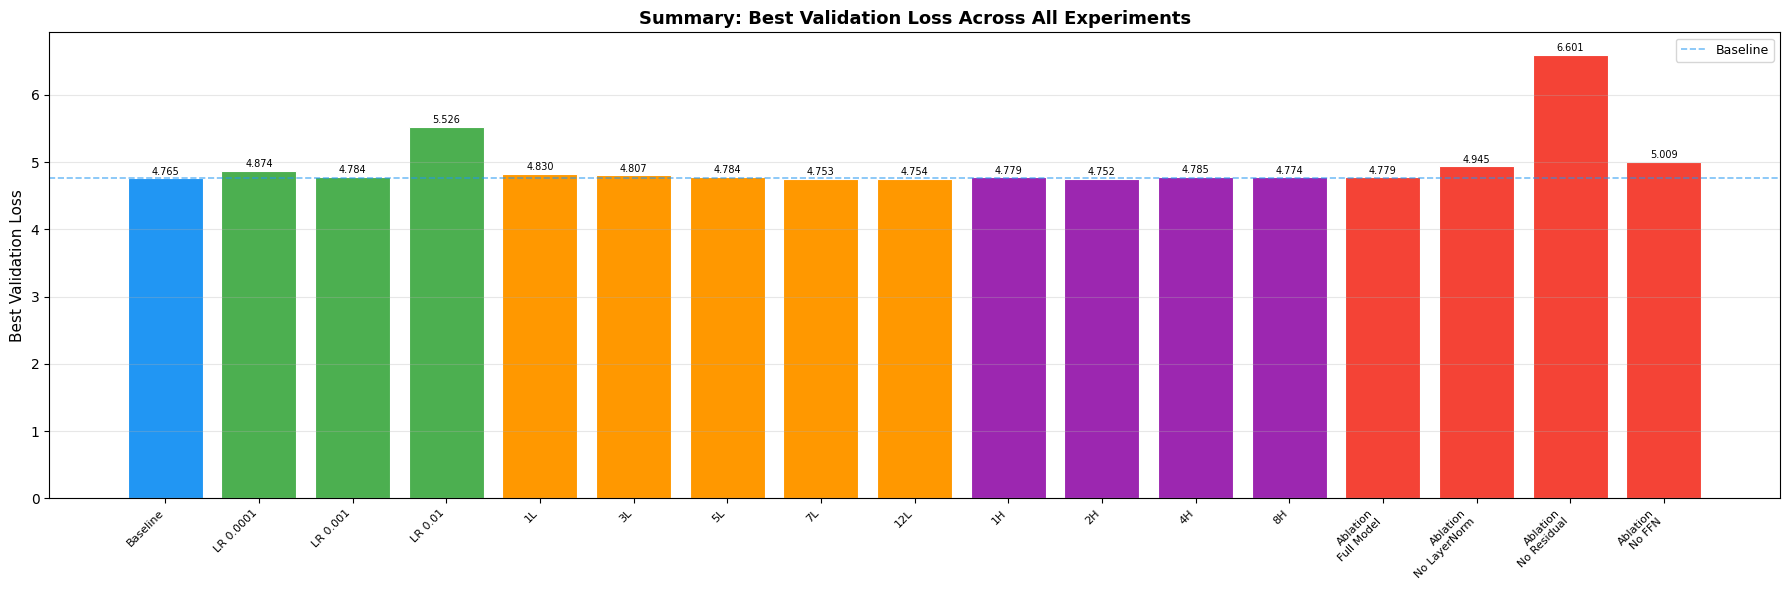

Summary bar chart saved: Summary_All_Experiments.png


In [ ]:
# ── Summary bar chart: best val loss across ALL experiments ──────────────

import json

with open("/kaggle/input/datasets/supermanrtyty/experiment-results-json/experiment_results.json") as f:
    data = json.load(f)

# Rebuild structures
baseline_history = {}
lr_histories = {}
layer_histories = {}
head_histories = {}
ablation_histories = {}

for d in data:
    label = d["label"]

    if label == "Baseline":
        baseline_history = {"best_val_loss": d["best_val_loss"]}

    elif "lr=" in label:
        lr_histories[label.split("=")[1]] = {"best_val_loss": d["best_val_loss"]}

    elif label == "EpochSweep":
        long_history = {"best_val_loss": d["best_val_loss"]}

    elif label.endswith("L"):
        layer_histories[label] = {"best_val_loss": d["best_val_loss"]}

    elif label.endswith("H"):
        head_histories[label] = {"best_val_loss": d["best_val_loss"]}

    elif label in ["Full Model", "No LayerNorm", "No Residual", "No FFN"]:
        ablation_histories[label] = {"best_val_loss": d["best_val_loss"]}

import matplotlib.pyplot as plt
import numpy as np

summary_labels = []
summary_vals   = []

# Baseline
summary_labels.append("Baseline")
summary_vals.append(baseline_history["best_val_loss"])

# Exp 1A LR
for k, h in lr_histories.items():
    summary_labels.append(f"LR {k}")
    summary_vals.append(h["best_val_loss"])

# Exp 2 Layers
for k, h in layer_histories.items():
    summary_labels.append(k)
    summary_vals.append(h["best_val_loss"])

# Exp 3 Heads
for k, h in head_histories.items():
    summary_labels.append(k)
    summary_vals.append(h["best_val_loss"])

# Exp 4 Ablation
for k, h in ablation_histories.items():
    summary_labels.append(f"Ablation\n{k}")
    summary_vals.append(h["best_val_loss"])

fig, ax = plt.subplots(figsize=(18, 6))
colors = (
    ["#2196F3"] +                       # baseline
    ["#4CAF50"] * len(lr_histories) +   # exp1a
    ["#FF9800"] * len(layer_histories) + # exp2
    ["#9C27B0"] * len(head_histories) + # exp3
    ["#F44336"] * len(ablation_histories) # exp4
)
bars = ax.bar(range(len(summary_labels)), summary_vals, color=colors, edgecolor="white", linewidth=0.8)
ax.set_xticks(range(len(summary_labels)))
ax.set_xticklabels(summary_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Best Validation Loss", fontsize=11)
ax.set_title("Summary: Best Validation Loss Across All Experiments", fontsize=13, fontweight="bold")
ax.axhline(baseline_history["best_val_loss"], color="#2196F3", linestyle="--", linewidth=1.2, alpha=0.6, label="Baseline")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, summary_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.savefig("Summary_All_Experiments.png", dpi=150, bbox_inches="tight")
plt.show()
print("Summary bar chart saved: Summary_All_Experiments.png")
